In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency
import warnings

warnings.filterwarnings("ignore")

In [2]:

# --- Plot Styling ---
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams.update({
    "figure.figsize": (12, 6),
    "figure.dpi": 120,
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.spines.top": False,
    "axes.spines.right": False,
})

# --- Nigerian Naira formatter for amount axes ---
def ngn_formatter(x, pos):
    if x >= 1_000_000:
        return f"₦{x/1_000_000:.1f}M"
    elif x >= 1_000:
        return f"₦{x/1_000:.0f}K"
    return f"₦{x:.0f}"

# --- Colour palette for fraud vs legitimate ---
FRAUD_PALETTE = {0: "#2196F3", 1: "#F44336"}  # Blue = legit, Red = fraud
FRAUD_LABELS  = {0: "Legitimate", 1: "Fraud"}

print("✅ Imports complete")

✅ Imports complete


In [3]:
from datasets import load_dataset

ds = load_dataset("kidnextdoor57/Nigerian-Financial-Transactions-and-Fraud-Detection-Dataset")

In [4]:
data = ds["train"].to_pandas()
data.head()

,transaction_id,timestamp,sender_account,receiver_account,transaction_type,merchant_category,location,device_used,is_fraud,fraud_type,...,txn_count_last_1h,txn_count_last_24h,total_amount_last_1h,time_since_last,avg_gap_between_txns,merchant_fraud_rate,channel_risk_score,persona_fraud_risk,location_fraud_risk,ip_geo_region
0,T2162315,2023-01-24 09:54:06.198396,1000018177,8385560081,deposit,Local Market Purchase,Aba,mobile,False,NaN,...,1,1,654135.08,0.000000,0.000000,0.1,0.8,0.5,0.1,South East
1,T1764581,2023-02-22 16:16:19.271951,1000018177,5643014197,payment,SPAR Purchase,Onitsha,mobile,False,NaN,...,2,2,687449.11,42142.217893,21071.108946,0.1,0.3,0.5,0.1,South East
2,T3305551,2023-05-04 16:01:42.312142,1000018177,7722691989,withdrawal,Other Transaction,Onitsha,web,False,NaN,...,3,3,719985.77,102225.384003,48122.533965,0.1,0.8,0.5,0.0,South East
3,T174955,2023-05-07 13:15:03.037215,1000018177,4987435115,payment,Ikeja Electric Bill,Benin City,atm,False,NaN,...,4,4,733430.88,4153.345418,37130.236828,0.1,0.3,0.5,0.1,South South
4,T3695059,2023-06-08 11:37:39.155188,1000018177,7939643449,withdrawal,Arik Air Flight,Aba,web,False,NaN,...,5,5,858543.44,45982.601966,38900.709856,0.1,0.6,0.5,0.0,South East


In [5]:
# --- Enforce correct dtypes ---

data["timestamp"] = pd.to_datetime(data["timestamp"])
data["is_fraud"] = data["is_fraud"].astype(int)

# --- Sort chronologically (critical for window features) ---

data = data.sort_values("timestamp").reset_index(drop=True)

In [6]:
print(f"✅ Dataset loaded: {data.shape[0]:,} rows × {data.shape[1]} columns")
print(f"   Date range : {data['timestamp'].min()} → {data['timestamp'].max()}")
print(f"   Memory     : {data.memory_usage(deep=True).sum() / 1e6:.1f} MB")

✅ Dataset loaded: 5,000,000 rows × 45 columns
   Date range : 2023-01-01 00:00:02.020872 → 2024-01-28 23:59:50.336777
   Memory     : 2242.1 MB


In [7]:
print("=" * 65)
print("DATASET SHAPE & DTYPES")
print("=" * 65)
print(data.dtypes.to_string())

DATASET SHAPE & DTYPES
transaction_id                            str
timestamp                      datetime64[us]
sender_account                          int64
receiver_account                        int64
transaction_type                          str
merchant_category                         str
location                                  str
device_used                               str
is_fraud                                int64
fraud_type                                str
time_since_last_transaction           float64
spending_deviation_score              float64
velocity_score                          int64
geo_anomaly_score                     float64
payment_channel                           str
ip_address                                str
device_hash                               str
amount_ngn                            float64
bvn_linked                               bool
new_device_transaction                   bool
sender_persona                            str
geospatial_

In [8]:
# --- Separate feature groups for later use ---
NUMERIC_COLS = data.select_dtypes(include=[np.number]).columns.tolist()
CATEGORICAL_COLS = data.select_dtypes(include=["object", "category"]).columns.tolist()
DATETIME_COLS = data.select_dtypes(include=["datetime"]).columns.tolist()


# Remove target and ID-like columns from numeric list

ID_COLS = ["transaction_id", "Sender_account", "Receiver_account"]
TARGET_COL = "is_fraud"
NUMERIC_FEATURES = [col for col in NUMERIC_COLS if col not in ID_COLS + [TARGET_COL]]

print(f"\nNumeric features  : {len(NUMERIC_FEATURES)}")
print(f"Categorical cols  : {len(CATEGORICAL_COLS)}")
print(f"Datetime cols     : {len(DATETIME_COLS)}")


Numeric features  : 28
Categorical cols  : 12
Datetime cols     : 1


In [9]:
# --- Cardinality of categoricals ---

print("\n" + "=" * 65)
print("CATEGORICAL CARDINALITY")
print("=" * 65)
cardinality = (
    data[CATEGORICAL_COLS]
    .nunique()
    .sort_values(ascending=False)
    .reset_index()
)
cardinality.columns = ["Column", "Unique Values"]
print(cardinality.to_string(index=False))

# --- Quick sample ---

print("\n" + "=" * 65)
print("SAMPLE ROWS (first 3)")
print("=" * 65)
display(data.head(3))


CATEGORICAL CARDINALITY
           Column  Unique Values
   transaction_id        5000000
      device_hash        3835723
       ip_address         362384
merchant_category             21
user_top_category             21
         location             10
    ip_geo_region              5
 transaction_type              4
      device_used              4
  payment_channel              4
       fraud_type              3
   sender_persona              3

SAMPLE ROWS (first 3)


,transaction_id,timestamp,sender_account,receiver_account,transaction_type,merchant_category,location,device_used,is_fraud,fraud_type,...,txn_count_last_1h,txn_count_last_24h,total_amount_last_1h,time_since_last,avg_gap_between_txns,merchant_fraud_rate,channel_risk_score,persona_fraud_risk,location_fraud_risk,ip_geo_region
0,T3968138,2023-01-01 00:00:02.020872,4778807568,1155776263,withdrawal,Other Transaction,Port Harcourt,atm,0,NaN,...,1,1,70038.15,0.0,0.0,0.036225,0.8,0.5,0.035833,South South
1,T436162,2023-01-01 00:00:13.463814,2213535317,4895777878,transfer,POS Withdrawal,Kano,web,0,NaN,...,1,1,107700.00,0.0,0.0,0.035596,0.4,0.7,0.035318,North West
2,T2232701,2023-01-01 00:00:35.539554,7153505013,2974787201,payment,Other Transaction,Enugu,pos,0,NaN,...,1,1,14623.08,0.0,0.0,0.035954,0.3,0.4,0.035596,South East


In [10]:
print("=" * 65)
print("ALL COLUMN NAMES & DTYPES")
print("=" * 65)
for col in data.columns:
    print(f"  {col:<35} {str(data[col].dtype):<15} nunique={data[col].nunique()}")

print("\n" + "=" * 65)
print("TECHNICAL / DEVICE / FLAG COLUMNS — VALUE COUNTS")
print("=" * 65)

# Columns we care about for Cell 11
suspect_cols = [
    c for c in data.columns
    if any(keyword in c.lower() for keyword in [
        "device", "ip", "bvn", "shared", "new", "flag", "seen"
    ])
]

for col in suspect_cols:
    print(f"\n--- {col} ---")
    print(data[col].value_counts().head(10))
    print(f"    dtype: {data[col].dtype} | nulls: {data[col].isnull().sum()}")

ALL COLUMN NAMES & DTYPES
  transaction_id                      str             nunique=5000000
  timestamp                           datetime64[us]  nunique=4999998
  sender_account                      int64           nunique=896458
  receiver_account                    int64           nunique=896584
  transaction_type                    str             nunique=4
  merchant_category                   str             nunique=21
  location                            str             nunique=10
  device_used                         str             nunique=4
  is_fraud                            int64           nunique=2
  fraud_type                          str             nunique=3
  time_since_last_transaction         float64         nunique=4103487
  spending_deviation_score            float64         nunique=917
  velocity_score                      int64           nunique=20
  geo_anomaly_score                   float64         nunique=101
  payment_channel                     str  

MISSING VALUE REPORT
                     Column  Missing Count  Missing %   Dtype
                 fraud_type        4820447      96.41     str
time_since_last_transaction         896513      17.93 float64


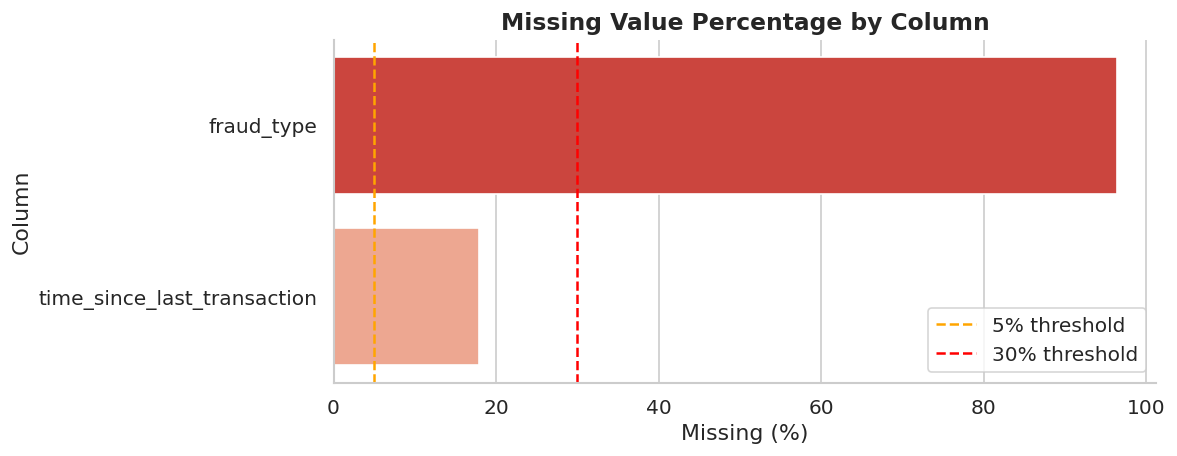

In [11]:
# Missing Values Analysis

missing = (
    data.isnull()
        .sum()
        .reset_index()
)
missing.columns = ["Column", "Missing Count"]
missing["Missing %"] = (missing["Missing Count"] / len(data) * 100).round(2)
missing["Dtype"]     = missing["Column"].map(data.dtypes)
missing = missing[missing["Missing Count"] > 0].sort_values(
    "Missing %", ascending=False
)

print("=" * 65)
print("MISSING VALUE REPORT")
print("=" * 65)
if missing.empty:
    print("✅ No missing values found.")
else:
    print(missing.to_string(index=False))
    
    # --- Visualise ---
    fig, ax = plt.subplots(figsize=(10, max(4, len(missing) * 0.5)))
    sns.barplot(
        data=missing, y="Column", x="Missing %",
        palette="Reds_r", ax=ax
    )
    ax.set_title("Missing Value Percentage by Column")
    ax.set_xlabel("Missing (%)")
    ax.axvline(5, color="orange", linestyle="--", label="5% threshold")
    ax.axvline(30, color="red", linestyle="--", label="30% threshold")
    ax.legend()
    plt.tight_layout()
    plt.savefig("eda_visuals/missing_values_report.png", bbox_inches="tight")
    plt.show()

In [12]:
# Target Variable Distribution

fraud_counts = data["is_fraud"].value_counts()
fraud_pct    = data["is_fraud"].value_counts(normalize=True) * 100

print("=" * 65)
print("TARGET VARIABLE DISTRIBUTION")
print("=" * 65)
print(f"  Legitimate transactions : {fraud_counts[0]:>10,}  ({fraud_pct[0]:.2f}%)")
print(f"  Fraud transactions      : {fraud_counts[1]:>10,}  ({fraud_pct[1]:.2f}%)")
print(f"  Imbalance ratio         : {fraud_counts[0]/fraud_counts[1]:.1f}:1")

TARGET VARIABLE DISTRIBUTION
  Legitimate transactions :  4,820,447  (96.41%)
  Fraud transactions      :    179,553  (3.59%)
  Imbalance ratio         : 26.8:1


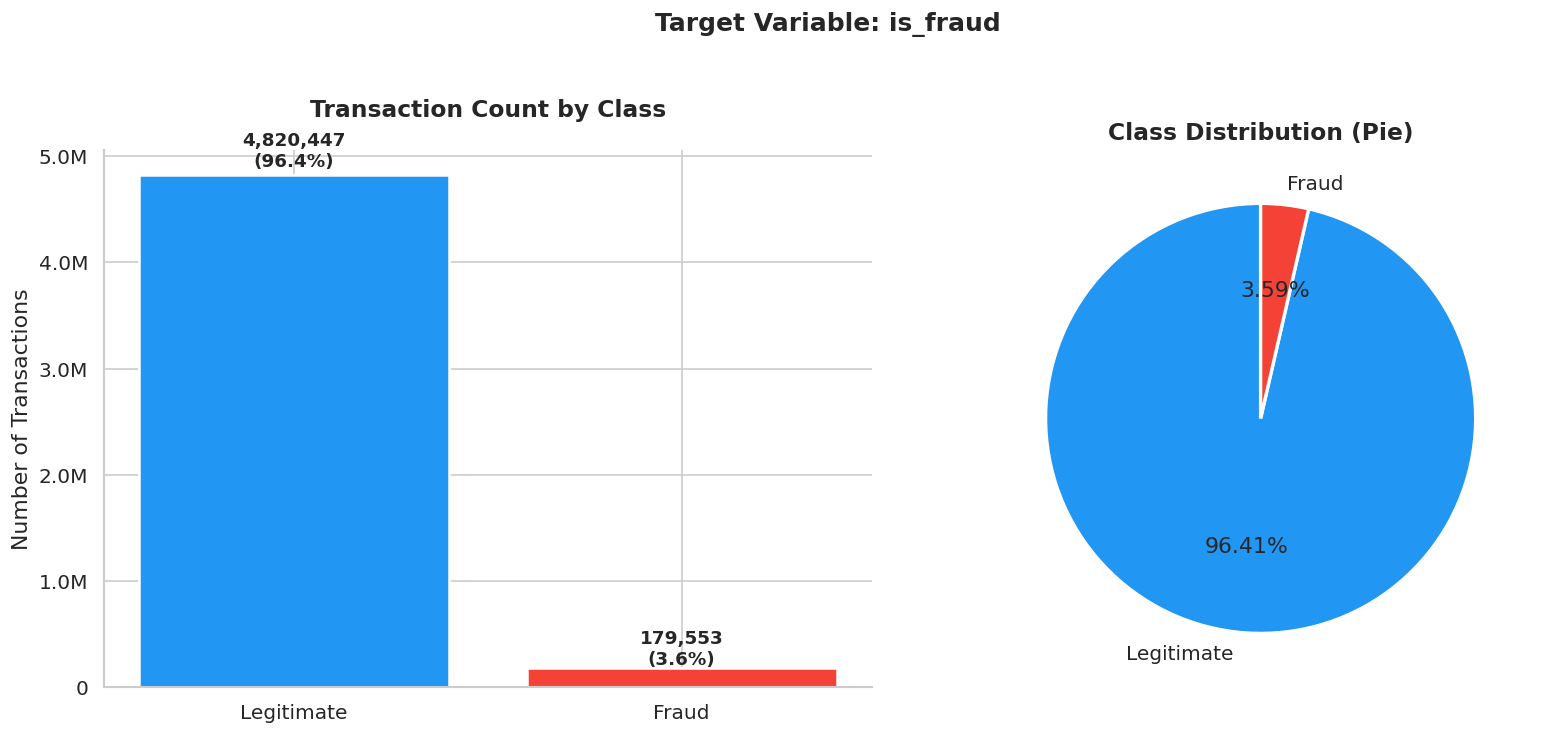

In [13]:
# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Bar chart
bars = axes[0].bar(
    ["Legitimate", "Fraud"],
    [fraud_counts[0], fraud_counts[1]],
    color=["#2196F3", "#F44336"],
    edgecolor="white", linewidth=1.5
)
axes[0].set_title("Transaction Count by Class", pad=20)
axes[0].set_ylabel("Number of Transactions")
axes[0].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M" if x >= 1e6 else f"{x:,.0f}")
)
for bar, val in zip(bars, [fraud_counts[0], fraud_counts[1]]):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() * 1.01,
        f"{val:,}\n({val/len(data)*100:.1f}%)",
        ha="center", va="bottom", fontsize=11, fontweight="bold"
    )

# Pie chart
axes[1].pie(
    [fraud_counts[0], fraud_counts[1]],
    labels=["Legitimate", "Fraud"],
    colors=["#2196F3", "#F44336"],
    autopct="%1.2f%%",
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 2}
)
axes[1].set_title("Class Distribution (Pie)")

plt.suptitle("Target Variable: is_fraud", fontsize=15, fontweight="bold", y=1.02)
plt.savefig("eda_visuals/target_distribution.png", bbox_inches="tight")
plt.tight_layout()
plt.show()


FRAUD TYPE BREAKDOWN
             Fraud Type  Count  Percentage
       Account Takeover 170415       94.91
         Identity Fraud   9126        5.08
Impossible Travel Fraud     12        0.01


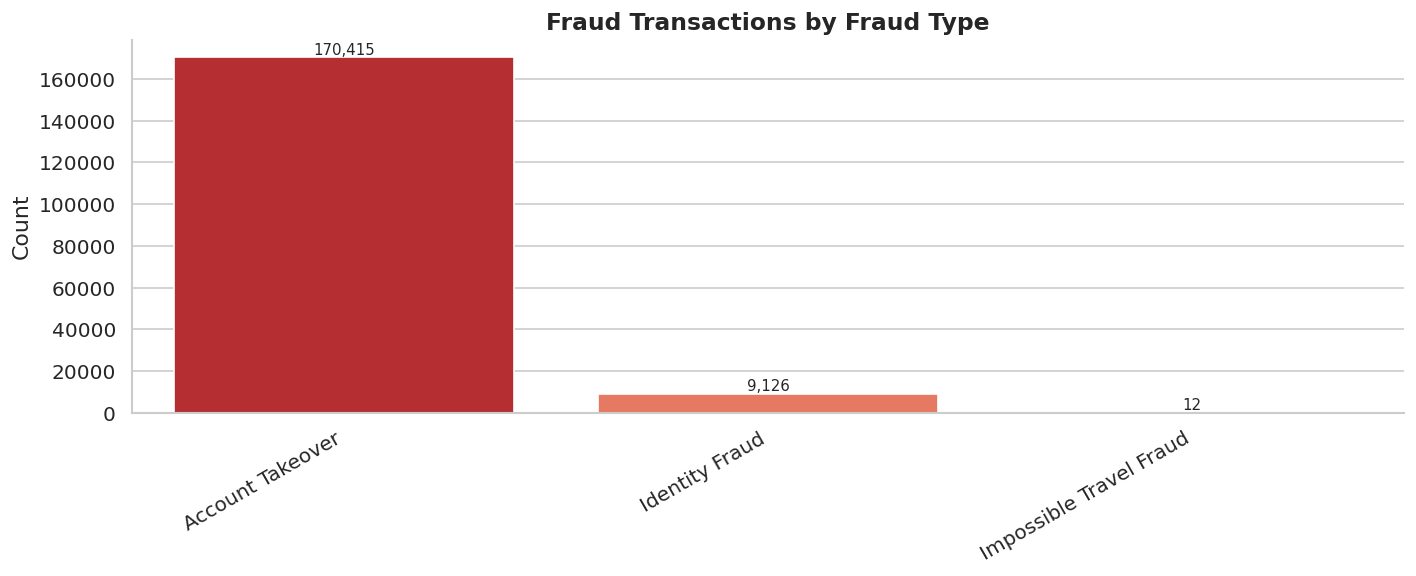

In [14]:
# --- Fraud type breakdown ---

print("\n" + "=" * 65)
print("FRAUD TYPE BREAKDOWN")
print("=" * 65)

fraud_type_dist = (
    data[data["is_fraud"] == 1]["fraud_type"]
    .value_counts()
    .reset_index()
)

fraud_type_dist.columns = ["Fraud Type", "Count"]
fraud_type_dist["Percentage"] = (
    fraud_type_dist["Count"] / fraud_type_dist["Count"].sum() * 100
).round(2)

print(fraud_type_dist.to_string(index=False))

fig, ax = plt.subplots(figsize=(12, 5))

sns.barplot(
    data=fraud_type_dist,
    x="Fraud Type", y="Count",
    palette="Reds_r", ax=ax
)

ax.set_title("Fraud Transactions by Fraud Type")
ax.set_xlabel("")
ax.set_ylabel("Count")
plt.xticks(rotation=30, ha="right")

for p in ax.patches:
    ax.annotate(
        f"{p.get_height():,.0f}",
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha="center", va="bottom", fontsize=9
    )

plt.tight_layout()
plt.savefig("eda_visuals/fraud_type_breakdown.png", bbox_inches="tight")
plt.show()

In [15]:
# Transaction Amount (NGN) Statistics

legit = data[data["is_fraud"] == 0]["amount_ngn"]
fraud = data[data["is_fraud"] == 1]["amount_ngn"]

print("=" * 65)
print("AMOUNT (NGN) STATISTICS")
print("=" * 65)

amount_stats = data.groupby("is_fraud")["amount_ngn"].describe()
amount_stats.index = ["Legitimate", "Fraud"]
print(amount_stats.round(2).to_string())

AMOUNT (NGN) STATISTICS
                count       mean         std    min       25%       50%        75%          max
Legitimate  4820447.0  748266.73  1545356.17  22.81  33204.98  163806.1  695696.43  22230669.54
Fraud        179553.0  748984.26  1549894.49  23.24  33326.31  163924.4  690531.74  20712162.49


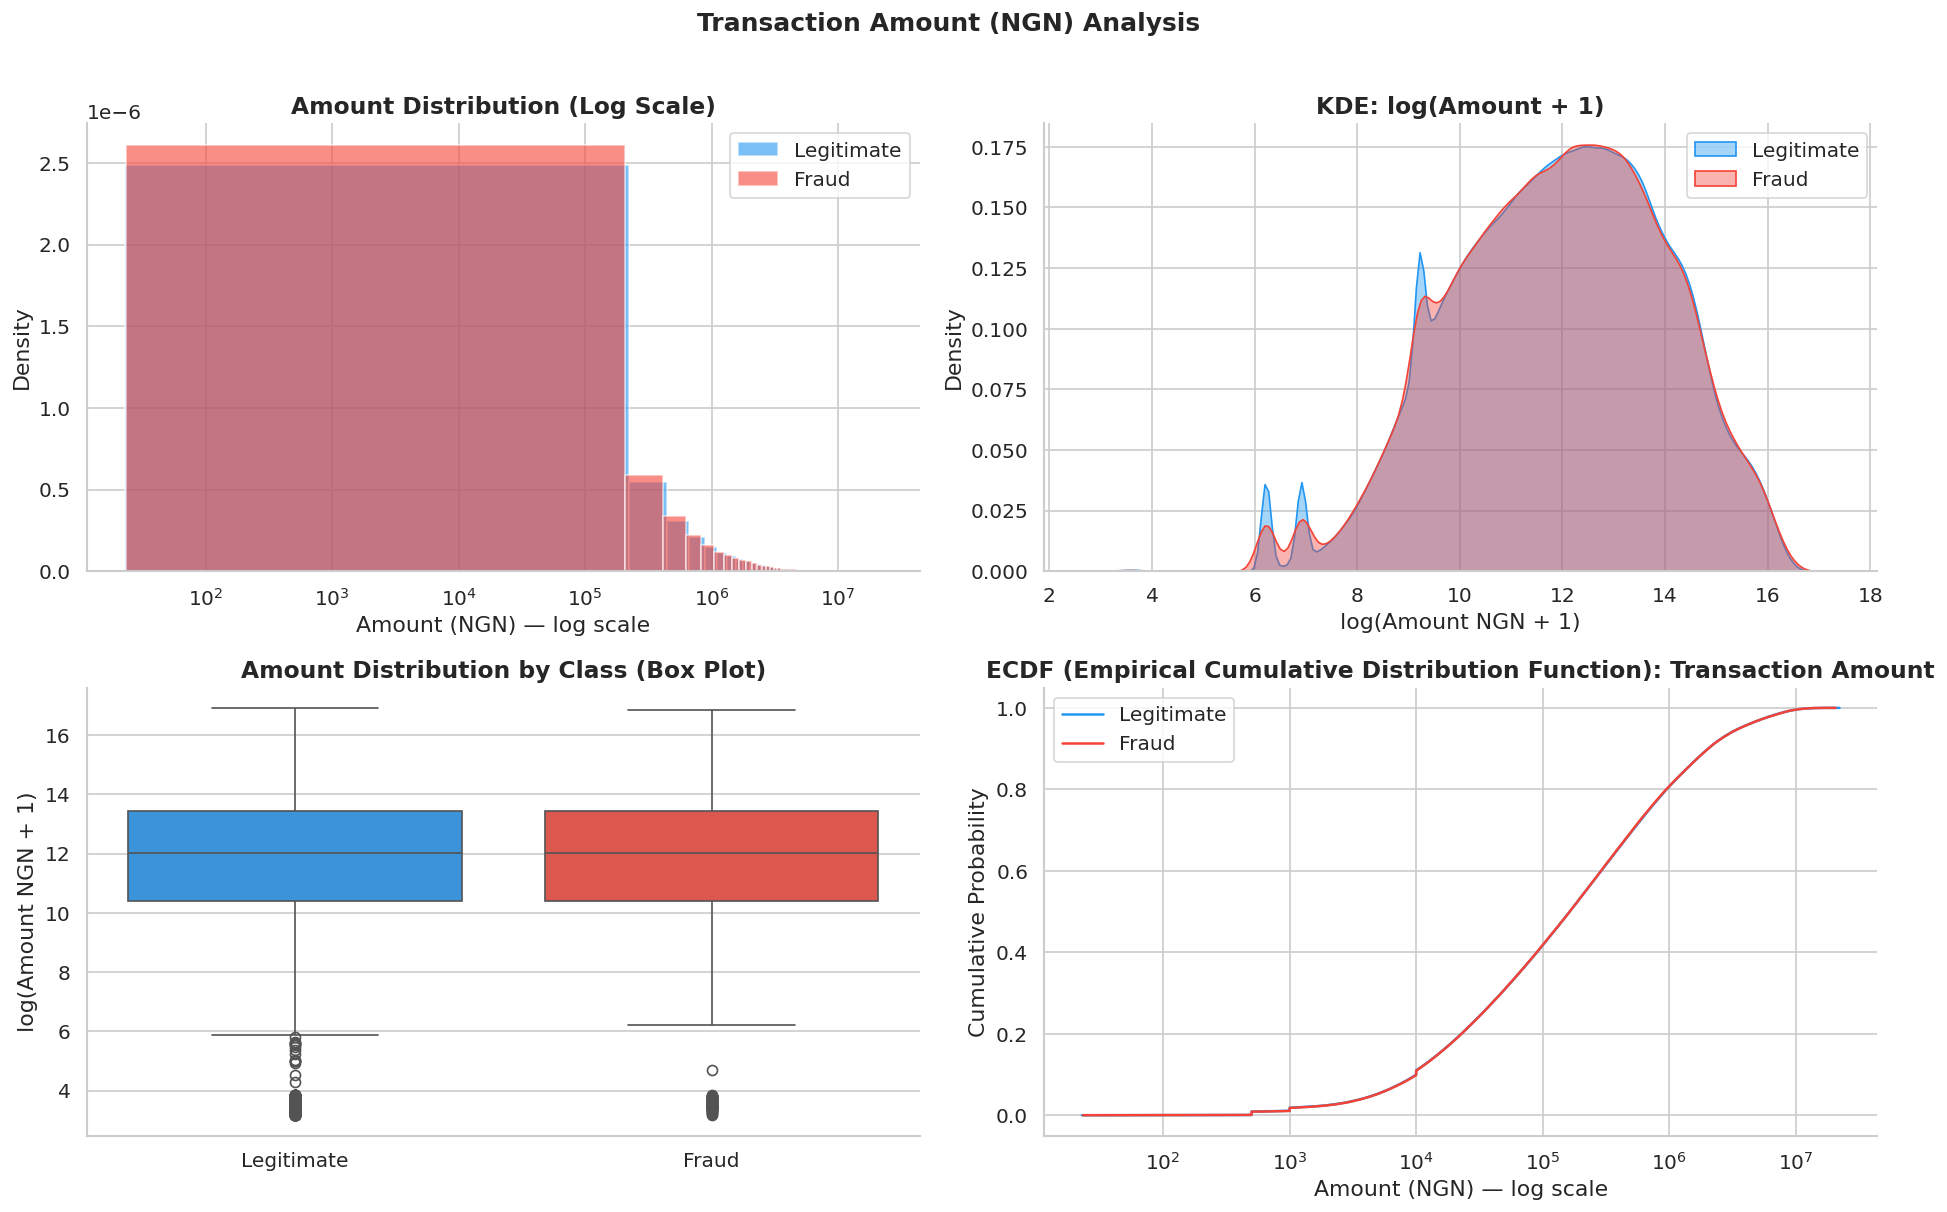


MANN-WHITNEY U TEST: Fraud vs Legitimate Amounts
  U-statistic : 432,580,994,312
  p-value     : 7.6201e-01
  Conclusion  : No significant difference ❌


In [16]:
# --- KDE + Histogram ---

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Raw distribution (log scale)

axes[0, 0].hist(
    legit, bins=100, alpha=0.6,
    color="#2196F3", label="Legitimate", density=True
)
axes[0, 0].hist(
    fraud, bins=100, alpha=0.6,
    color="#F44336", label="Fraud", density=True
)
axes[0, 0].set_xscale("log")
axes[0, 0].set_title("Amount Distribution (Log Scale)")
axes[0, 0].set_xlabel("Amount (NGN) — log scale")
axes[0, 0].set_ylabel("Density")
axes[0, 0].legend()

# KDE on log-transformed amounts

log_legit = np.log1p(legit)
log_fraud = np.log1p(fraud)
axes[0, 1].set_title("KDE: log(Amount + 1)")
sns.kdeplot(log_legit, ax=axes[0, 1], color="#2196F3",
            label="Legitimate", fill=True, alpha=0.4)
sns.kdeplot(log_fraud, ax=axes[0, 1], color="#F44336",
            label="Fraud", fill=True, alpha=0.4)
axes[0, 1].set_xlabel("log(Amount NGN + 1)")
axes[0, 1].legend()

# Box plot

axes[1, 0].set_title("Amount Distribution by Class (Box Plot)")
data_plot = data.copy()
data_plot["log_amount"] = np.log1p(data_plot["amount_ngn"])
data_plot["label"] = data_plot["is_fraud"].map(FRAUD_LABELS)
sns.boxplot(
    data=data_plot, x="label", y="log_amount",
    palette={"Legitimate": "#2196F3", "Fraud": "#F44336"},
    ax=axes[1, 0]
)
axes[1, 0].set_xlabel("")
axes[1, 0].set_ylabel("log(Amount NGN + 1)")

# ECDF (Empirical Cumulative Distribution Function)

axes[1, 1].set_title("ECDF (Empirical Cumulative Distribution Function): Transaction Amount")
for subset, label, color in [
    (legit, "Legitimate", "#2196F3"),
    (fraud, "Fraud", "#F44336")
]:
    sorted_vals = np.sort(subset)
    ecdf = np.arange(1, len(sorted_vals) + 1) / len(sorted_vals)
    axes[1, 1].plot(sorted_vals, ecdf, label=label, color=color, linewidth=1.5)
axes[1, 1].set_xscale("log")
axes[1, 1].set_xlabel("Amount (NGN) — log scale")
axes[1, 1].set_ylabel("Cumulative Probability")
axes[1, 1].legend()

plt.suptitle("Transaction Amount (NGN) Analysis", fontsize=15,
             fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("eda_visuals/amount_distribution_analysis.png", bbox_inches="tight")
plt.show()

# --- Statistical test ---
print("\n" + "=" * 65)
print("MANN-WHITNEY U TEST: Fraud vs Legitimate Amounts")
print("=" * 65)

# Rationale: Mann-Whitney is used (not t-test) because amount
# is highly skewed — we cannot assume normality.

stat, p_val = stats.mannwhitneyu(fraud, legit, alternative="two-sided")
print(f"  U-statistic : {stat:,.0f}")
print(f"  p-value     : {p_val:.4e}")
print(f"  Conclusion  : {'Significant difference ✅' if p_val < 0.05 else 'No significant difference ❌'}")

PAYMENT CHANNEL FRAUD ANALYSIS
payment_channel   total  fraud_count    avg_amount  channel_risk_score  empirical_fraud_rate
           USSD 1249555        45108 749732.218424                 0.8                  3.61
           Card 1248434        44834 746657.592542                 0.4                  3.59
     Mobile App 1250847        44882 749351.346467                 0.6                  3.59
  Bank Transfer 1251164        44729 747427.375905                 0.3                  3.57

💡 Compare 'channel_risk_score' vs 'empirical_fraud_rate'
   If aligned → pre-computed risk score is valid
   If misaligned → we must recompute from data


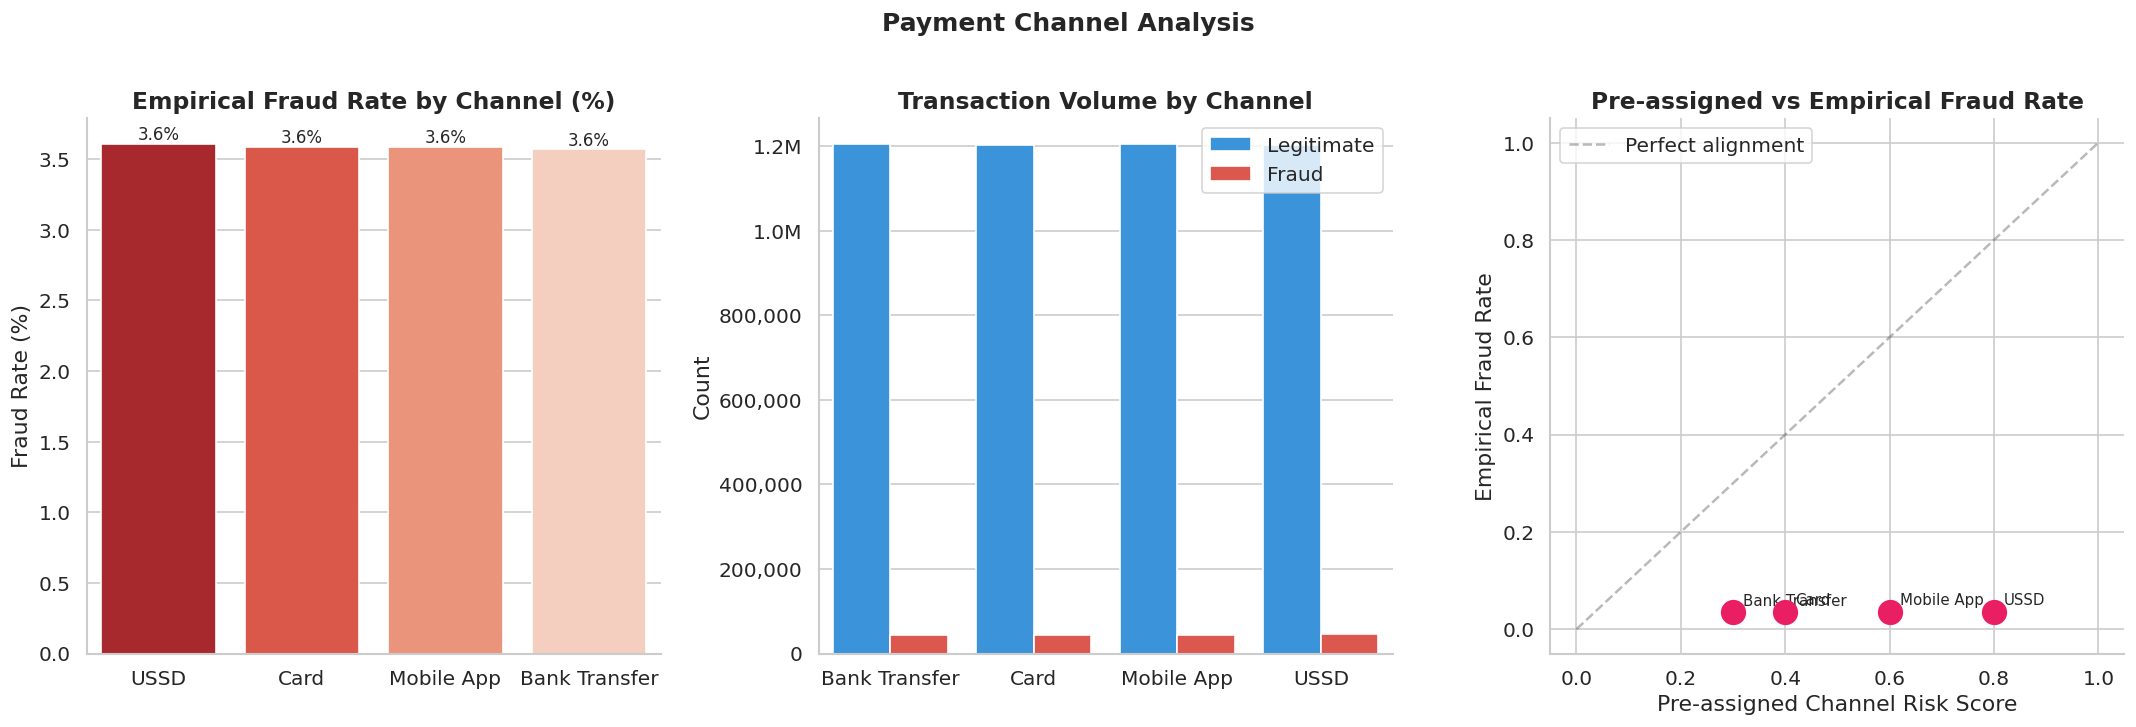

In [17]:
# Payment Channel Analysis

channel_stats = (
    data.groupby("payment_channel")
    .agg(
        total=("is_fraud", "count"),
        fraud_count=("is_fraud", "sum"),
        avg_amount=("amount_ngn", "mean"),
        channel_risk_score=("channel_risk_score", "first")
    )
    .reset_index()
)
channel_stats["empirical_fraud_rate"] = (
    channel_stats["fraud_count"] / channel_stats["total"] * 100
).round(2)
channel_stats = channel_stats.sort_values(
    "empirical_fraud_rate", ascending=False
)

print("=" * 65)
print("PAYMENT CHANNEL FRAUD ANALYSIS")
print("=" * 65)
print(channel_stats.to_string(index=False))
print("\n💡 Compare 'channel_risk_score' vs 'empirical_fraud_rate'")
print("   If aligned → pre-computed risk score is valid")
print("   If misaligned → we must recompute from data")

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Fraud rate by channel

sns.barplot(
    data=channel_stats,
    x="payment_channel",
    y="empirical_fraud_rate",
    palette="Reds_r", ax=axes[0]
)

axes[0].set_title("Empirical Fraud Rate by Channel (%)")
axes[0].set_xlabel("")
axes[0].set_ylabel("Fraud Rate (%)")
for p in axes[0].patches:
    axes[0].annotate(
        f"{p.get_height():.1f}%",
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha="center", va="bottom", fontsize=10
    )

# Transaction volume by channel

channel_pivot = data.groupby(
    ["payment_channel", "is_fraud"]
).size().reset_index(name="count")
channel_pivot["label"] = channel_pivot["is_fraud"].map(FRAUD_LABELS)
sns.barplot(
    data=channel_pivot,
    x="payment_channel", y="count",
    hue="label",
    palette={"Legitimate": "#2196F3", "Fraud": "#F44336"},
    ax=axes[1]
)
axes[1].set_title("Transaction Volume by Channel")
axes[1].set_xlabel("")
axes[1].set_ylabel("Count")
axes[1].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M" if x >= 1e6 else f"{x:,.0f}")
)
axes[1].legend(title="")

# Pre-assigned vs empirical risk score comparison

axes[2].scatter(
    channel_stats["channel_risk_score"],
    channel_stats["empirical_fraud_rate"] / 100,
    s=200, zorder=5, color="#E91E63"
)
for _, row in channel_stats.iterrows():
    axes[2].annotate(
        row["payment_channel"],
        (row["channel_risk_score"], row["empirical_fraud_rate"] / 100),
        textcoords="offset points", xytext=(6, 4), fontsize=9
    )
axes[2].plot([0, 1], [0, 1], "k--", alpha=0.3, label="Perfect alignment")
axes[2].set_title("Pre-assigned vs Empirical Fraud Rate")
axes[2].set_xlabel("Pre-assigned Channel Risk Score")
axes[2].set_ylabel("Empirical Fraud Rate")
axes[2].legend()

plt.suptitle("Payment Channel Analysis", fontsize=15,
             fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("eda_visuals/payment_channel_analysis.png", bbox_inches="tight")
plt.show()

CITY-LEVEL FRAUD ANALYSIS
     location  total  fraud_count  location_fraud_risk    avg_amount  empirical_fraud_rate
       Kaduna 501261        18256             0.036364 746196.858596                  3.64
        Abuja 500405        18163             0.036406 745422.332495                  3.63
      Onitsha 499953        18033             0.037821 748699.569737                  3.61
         Kano 501097        18037             0.035318 753265.299209                  3.60
        Lagos 499140        17895             0.036016 751523.630116                  3.59
   Benin City 500690        17994             0.036747 745693.729511                  3.59
       Ibadan 497912        17859             0.035764 750068.603094                  3.59
          Aba 498643        17771             0.035593 748417.587598                  3.56
        Enugu 500964        17825             0.035596 746364.612096                  3.56
Port Harcourt 499935        17720             0.035833 747289.95

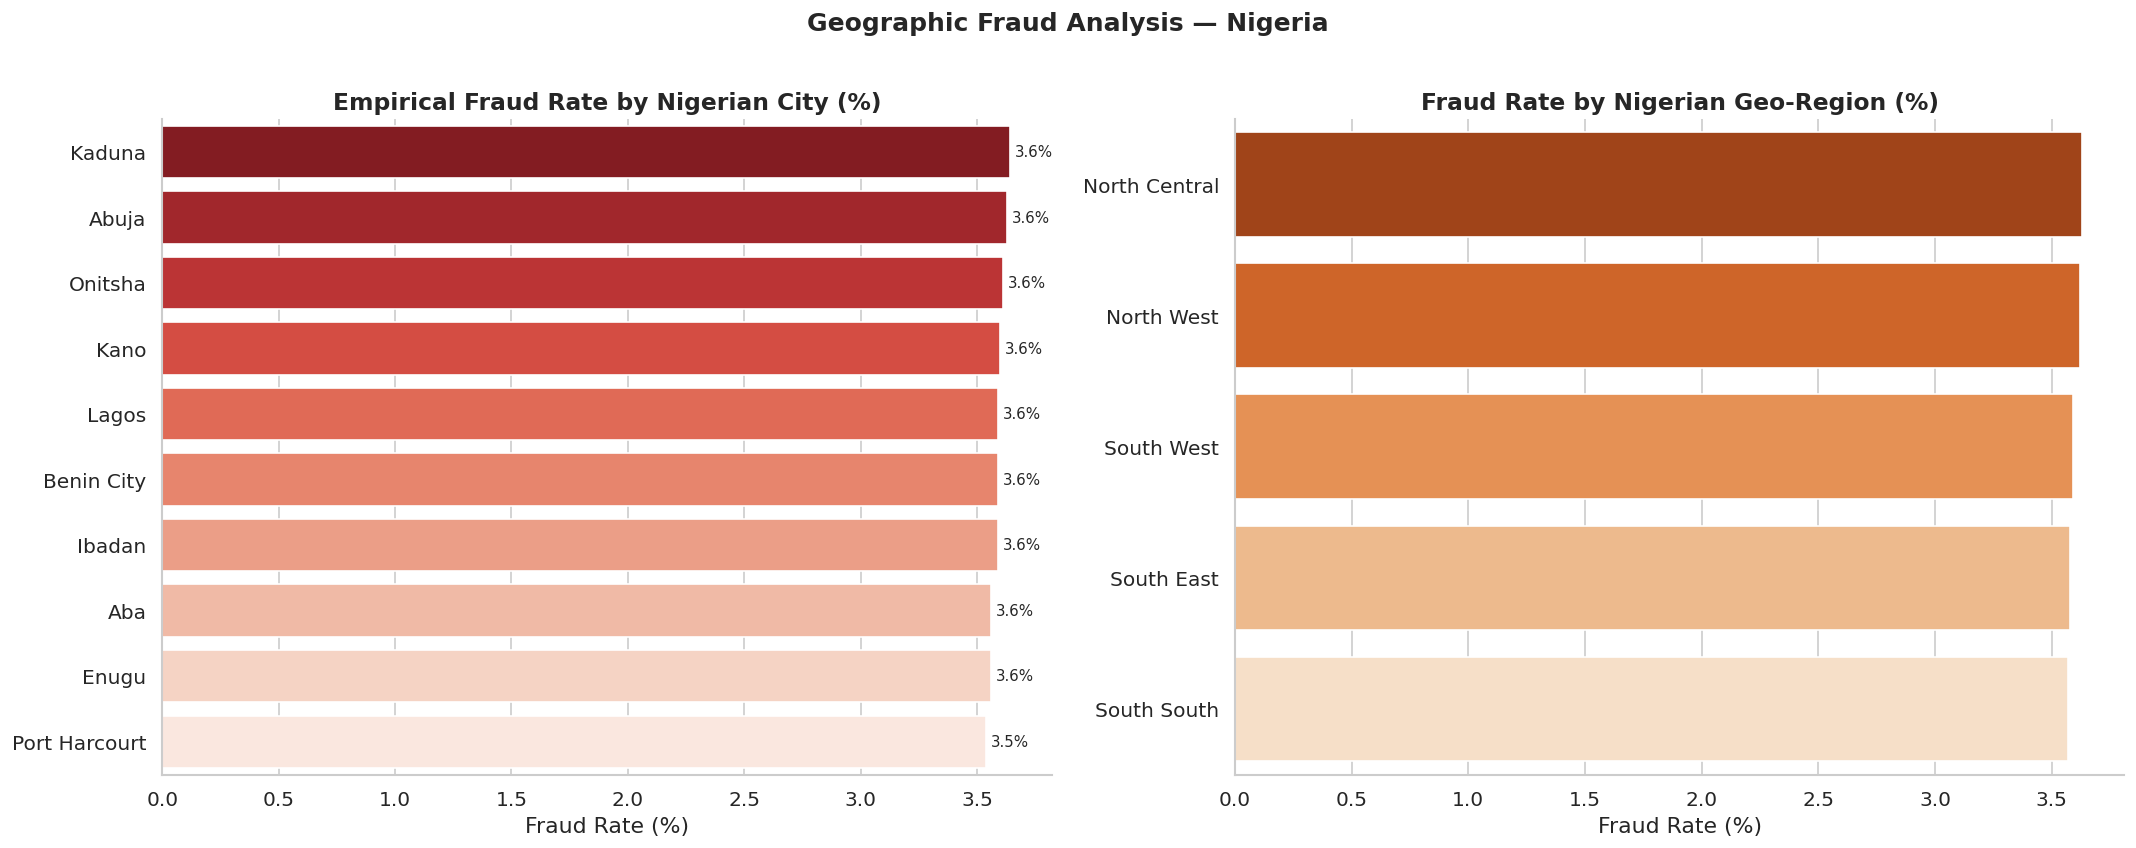


GEOSPATIAL VELOCITY ANOMALY FLAG
                  Legitimate %  Fraud %
No Anomaly               96.41     3.59
Anomaly Detected         96.89     3.11
All                      96.41     3.59


In [18]:
# Geographical Analysis

city_stats = (
    data.groupby("location")
    .agg(
        total=("is_fraud", "count"),
        fraud_count=("is_fraud", "sum"),
        location_fraud_risk=("location_fraud_risk", "first"),
        avg_amount=("amount_ngn", "mean")
    )
    .reset_index()
)

city_stats["empirical_fraud_rate"] = (
    city_stats["fraud_count"] / city_stats["total"] * 100
).round(2)
city_stats = city_stats.sort_values("empirical_fraud_rate", ascending=False)

print("=" * 65)
print("CITY-LEVEL FRAUD ANALYSIS")
print("=" * 65)
print(city_stats.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Fraud rate by city

sns.barplot(
    data=city_stats,
    x="empirical_fraud_rate",
    y="location",
    palette="Reds_r", ax=axes[0]
)
axes[0].set_title("Empirical Fraud Rate by Nigerian City (%)")
axes[0].set_xlabel("Fraud Rate (%)")
axes[0].set_ylabel("")
for p in axes[0].patches:
    axes[0].annotate(
        f"{p.get_width():.1f}%",
        (p.get_width(), p.get_y() + p.get_height() / 2),
        ha="left", va="center", fontsize=9, xytext=(3, 0),
        textcoords="offset points"
    )

# Geo-region level

region_stats = (
    data.groupby("ip_geo_region")
    .agg(
        total=("is_fraud", "count"),
        fraud_count=("is_fraud", "sum")
    )
    .reset_index()
)
region_stats["fraud_rate"] = (
    region_stats["fraud_count"] / region_stats["total"] * 100
).round(2)
region_stats = region_stats.sort_values("fraud_rate", ascending=False)

sns.barplot(
    data=region_stats,
    x="fraud_rate", y="ip_geo_region",
    palette="Oranges_r", ax=axes[1]
)
axes[1].set_title("Fraud Rate by Nigerian Geo-Region (%)")
axes[1].set_xlabel("Fraud Rate (%)")
axes[1].set_ylabel("")

plt.suptitle("Geographic Fraud Analysis — Nigeria",
             fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("eda_visuals/geographic_fraud_analysis.png", bbox_inches="tight")
plt.show()

# --- Geospatial velocity anomaly ---

print("\n" + "=" * 65)
print("GEOSPATIAL VELOCITY ANOMALY FLAG")
print("=" * 65)

# Rationale: This flag marks "impossible travel", a strong fraud
# signal. We check: how often does it fire? Is it actually
# correlated with fraud labels?

geo_cross = pd.crosstab(
    data["geospatial_velocity_anomaly"],
    data["is_fraud"],
    margins=True,
    normalize="index"
).round(4) * 100

geo_cross.index = ["No Anomaly", "Anomaly Detected", "All"]
geo_cross.columns = ["Legitimate %", "Fraud %"]
print(geo_cross.to_string())

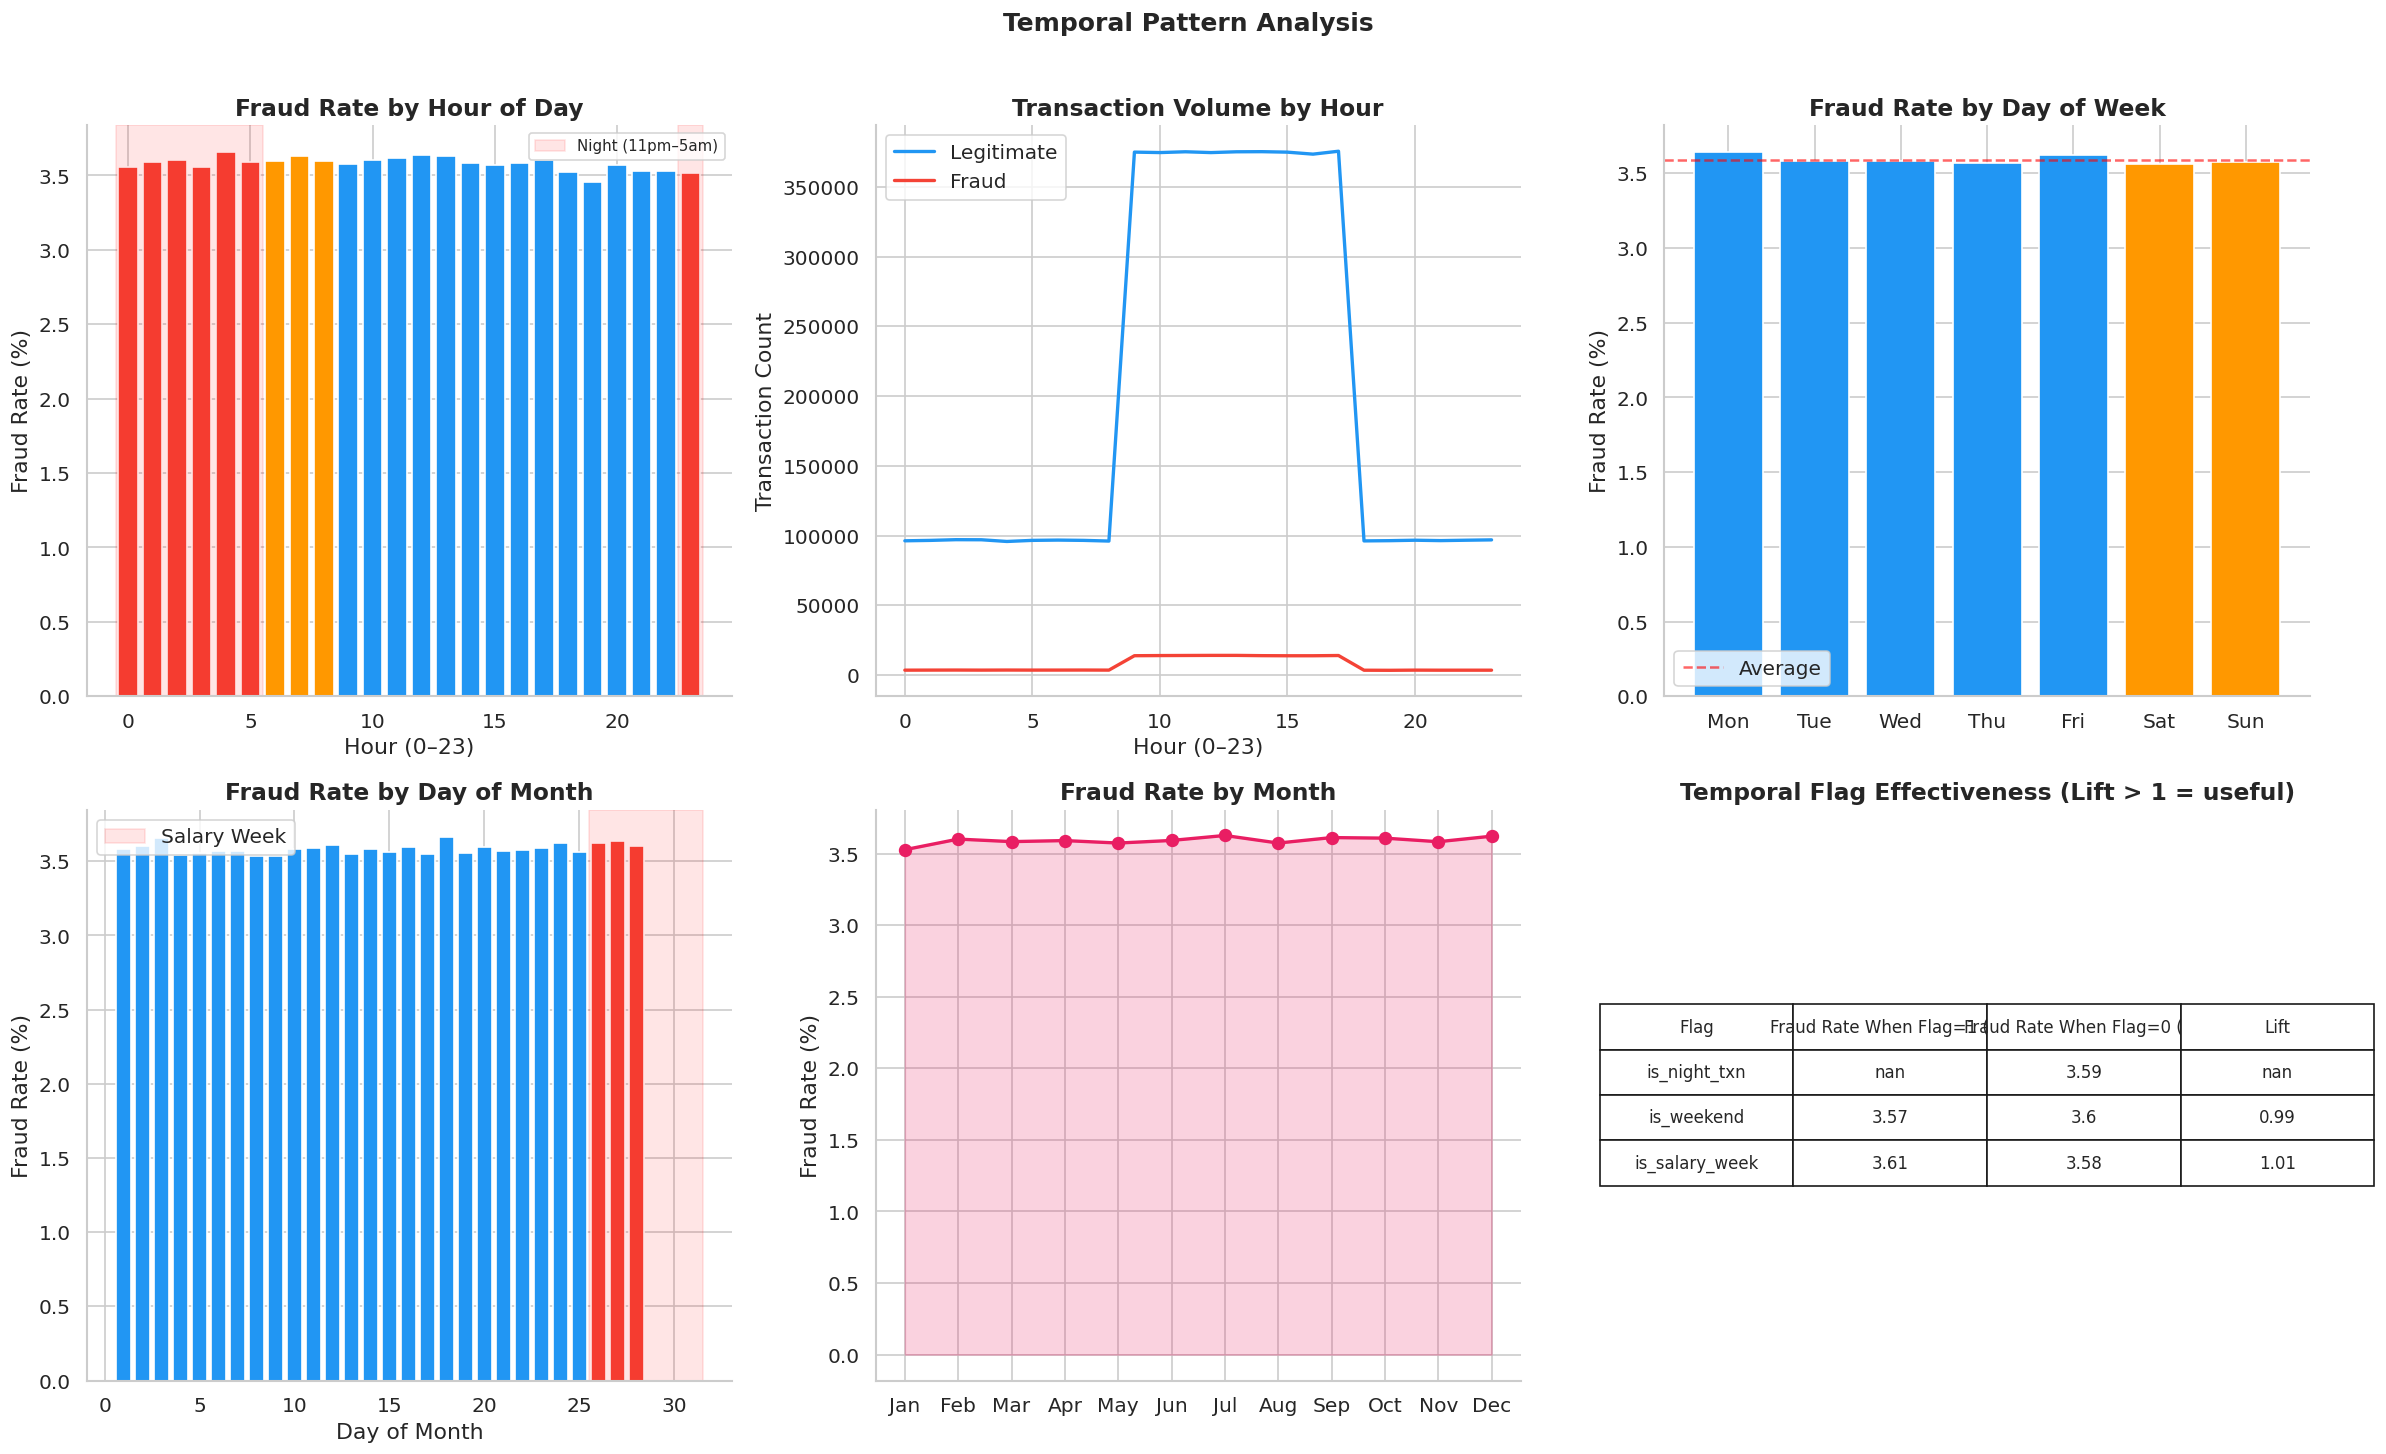

In [19]:
# Temporal Pattern Analysis

# --- Extract temporal components from raw timestamp ---

data["hour"]       = data["timestamp"].dt.hour
data["day_of_week"]= data["timestamp"].dt.dayofweek  # 0=Monday
data["day_of_month"]= data["timestamp"].dt.day
data["month"]      = data["timestamp"].dt.month
data["week_label"] = data["day_of_week"].map({
    0:"Mon", 1:"Tue", 2:"Wed", 3:"Thu", 4:"Fri", 5:"Sat", 6:"Sun"
})

fig, axes = plt.subplots(2, 3, figsize=(20, 12))

# --- Hourly fraud rate ---

hourly = (
    data.groupby("hour")
    .agg(total=("is_fraud", "count"), fraud=("is_fraud", "sum"))
    .reset_index()
)
hourly["fraud_rate"] = hourly["fraud"] / hourly["total"] * 100

axes[0, 0].bar(
    hourly["hour"], hourly["fraud_rate"],
    color=[
        "#F44336" if (h >= 23 or h <= 5) else "#FF9800" if h <= 8 else "#2196F3"
        for h in hourly["hour"]
    ]
)
axes[0, 0].set_title("Fraud Rate by Hour of Day")
axes[0, 0].set_xlabel("Hour (0–23)")
axes[0, 0].set_ylabel("Fraud Rate (%)")
axes[0, 0].axvspan(-0.5, 5.5, alpha=0.1, color="red", label="Night (11pm–5am)")
axes[0, 0].axvspan(22.5, 23.5, alpha=0.1, color="red")
axes[0, 0].legend(fontsize=9)

# --- Transaction volume by hour ---
hourly_vol = data.groupby(["hour", "is_fraud"]).size().reset_index(name="count")
hourly_vol["label"] = hourly_vol["is_fraud"].map(FRAUD_LABELS)
sns.lineplot(
    data=hourly_vol, x="hour", y="count",
    hue="label",
    palette={"Legitimate": "#2196F3", "Fraud": "#F44336"},
    ax=axes[0, 1], linewidth=2
)
axes[0, 1].set_title("Transaction Volume by Hour")
axes[0, 1].set_xlabel("Hour (0–23)")
axes[0, 1].set_ylabel("Transaction Count")
axes[0, 1].legend(title="")

# --- Day of week fraud rate ---
dow_stats = (
    data.groupby(["day_of_week", "week_label"])
    .agg(total=("is_fraud", "count"), fraud=("is_fraud", "sum"))
    .reset_index()
)
dow_stats["fraud_rate"] = dow_stats["fraud"] / dow_stats["total"] * 100
dow_stats = dow_stats.sort_values("day_of_week")

axes[0, 2].bar(
    dow_stats["week_label"], dow_stats["fraud_rate"],
    color=["#FF9800" if d >= 5 else "#2196F3" for d in dow_stats["day_of_week"]]
)
axes[0, 2].set_title("Fraud Rate by Day of Week")
axes[0, 2].set_xlabel("")
axes[0, 2].set_ylabel("Fraud Rate (%)")
axes[0, 2].axhline(
    dow_stats["fraud_rate"].mean(),
    color="red", linestyle="--", alpha=0.6, label="Average"
)
axes[0, 2].legend()

# --- Day of month fraud rate (salary week check) ---
dom_stats = (
    data.groupby("day_of_month")
    .agg(total=("is_fraud", "count"), fraud=("is_fraud", "sum"))
    .reset_index()
)
dom_stats["fraud_rate"] = dom_stats["fraud"] / dom_stats["total"] * 100

axes[1, 0].bar(
    dom_stats["day_of_month"], dom_stats["fraud_rate"],
    color=[
        "#F44336" if d >= 26 else "#2196F3"
        for d in dom_stats["day_of_month"]
    ]
)
axes[1, 0].set_title("Fraud Rate by Day of Month")
axes[1, 0].set_xlabel("Day of Month")
axes[1, 0].set_ylabel("Fraud Rate (%)")
axes[1, 0].axvspan(25.5, 31.5, alpha=0.1, color="red", label="Salary Week")
axes[1, 0].legend()

# --- Monthly trend ---
monthly = (
    data.groupby("month")
    .agg(total=("is_fraud", "count"), fraud=("is_fraud", "sum"))
    .reset_index()
)
monthly["fraud_rate"] = monthly["fraud"] / monthly["total"] * 100
month_names = {
    1:"Jan", 2:"Feb", 3:"Mar", 4:"Apr", 5:"May", 6:"Jun",
    7:"Jul", 8:"Aug", 9:"Sep", 10:"Oct", 11:"Nov", 12:"Dec"
}
monthly["month_name"] = monthly["month"].map(month_names)

axes[1, 1].plot(
    monthly["month_name"], monthly["fraud_rate"],
    marker="o", color="#E91E63", linewidth=2, markersize=7
)
axes[1, 1].fill_between(
    monthly["month_name"], monthly["fraud_rate"],
    alpha=0.2, color="#E91E63"
)
axes[1, 1].set_title("Fraud Rate by Month")
axes[1, 1].set_xlabel("")
axes[1, 1].set_ylabel("Fraud Rate (%)")

# --- Pre-computed flags verification ---
flag_comparison = pd.DataFrame({
    "Flag": ["is_night_txn", "is_weekend", "is_salary_week"],
    "Fraud Rate When Flag=1 (%)": [
        data[data["is_night_txn"] == 1]["is_fraud"].mean() * 100,
        data[data["is_weekend"] == 1]["is_fraud"].mean() * 100,
        data[data["is_salary_week"] == 1]["is_fraud"].mean() * 100
    ],
    "Fraud Rate When Flag=0 (%)": [
        data[data["is_night_txn"] == 0]["is_fraud"].mean() * 100,
        data[data["is_weekend"] == 0]["is_fraud"].mean() * 100,
        data[data["is_salary_week"] == 0]["is_fraud"].mean() * 100
    ]
})
flag_comparison["Lift"] = (
    flag_comparison["Fraud Rate When Flag=1 (%)"] /
    flag_comparison["Fraud Rate When Flag=0 (%)"]
).round(2)

axes[1, 2].axis("off")
table = axes[1, 2].table(
    cellText=flag_comparison.round(2).values,
    colLabels=flag_comparison.columns,
    loc="center", cellLoc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 2)
axes[1, 2].set_title("Temporal Flag Effectiveness (Lift > 1 = useful)",
                      fontweight="bold")

plt.suptitle("Temporal Pattern Analysis", fontsize=15,
             fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("eda_visuals/temporal_pattern_analysis.png", bbox_inches="tight")
plt.show()

USER PERSONA ANALYSIS
sender_persona   total  fraud_count   avg_amount  median_amount  persona_fraud_risk  empirical_fraud_rate
 Salary Earner 1663557        59614 5.027047e+05     180584.830                 0.4                  3.58
       Student 1672920        60083 1.634357e+05      56050.855                 0.5                  3.59
        Trader 1663523        59856 1.582046e+06     528064.540                 0.7                  3.60


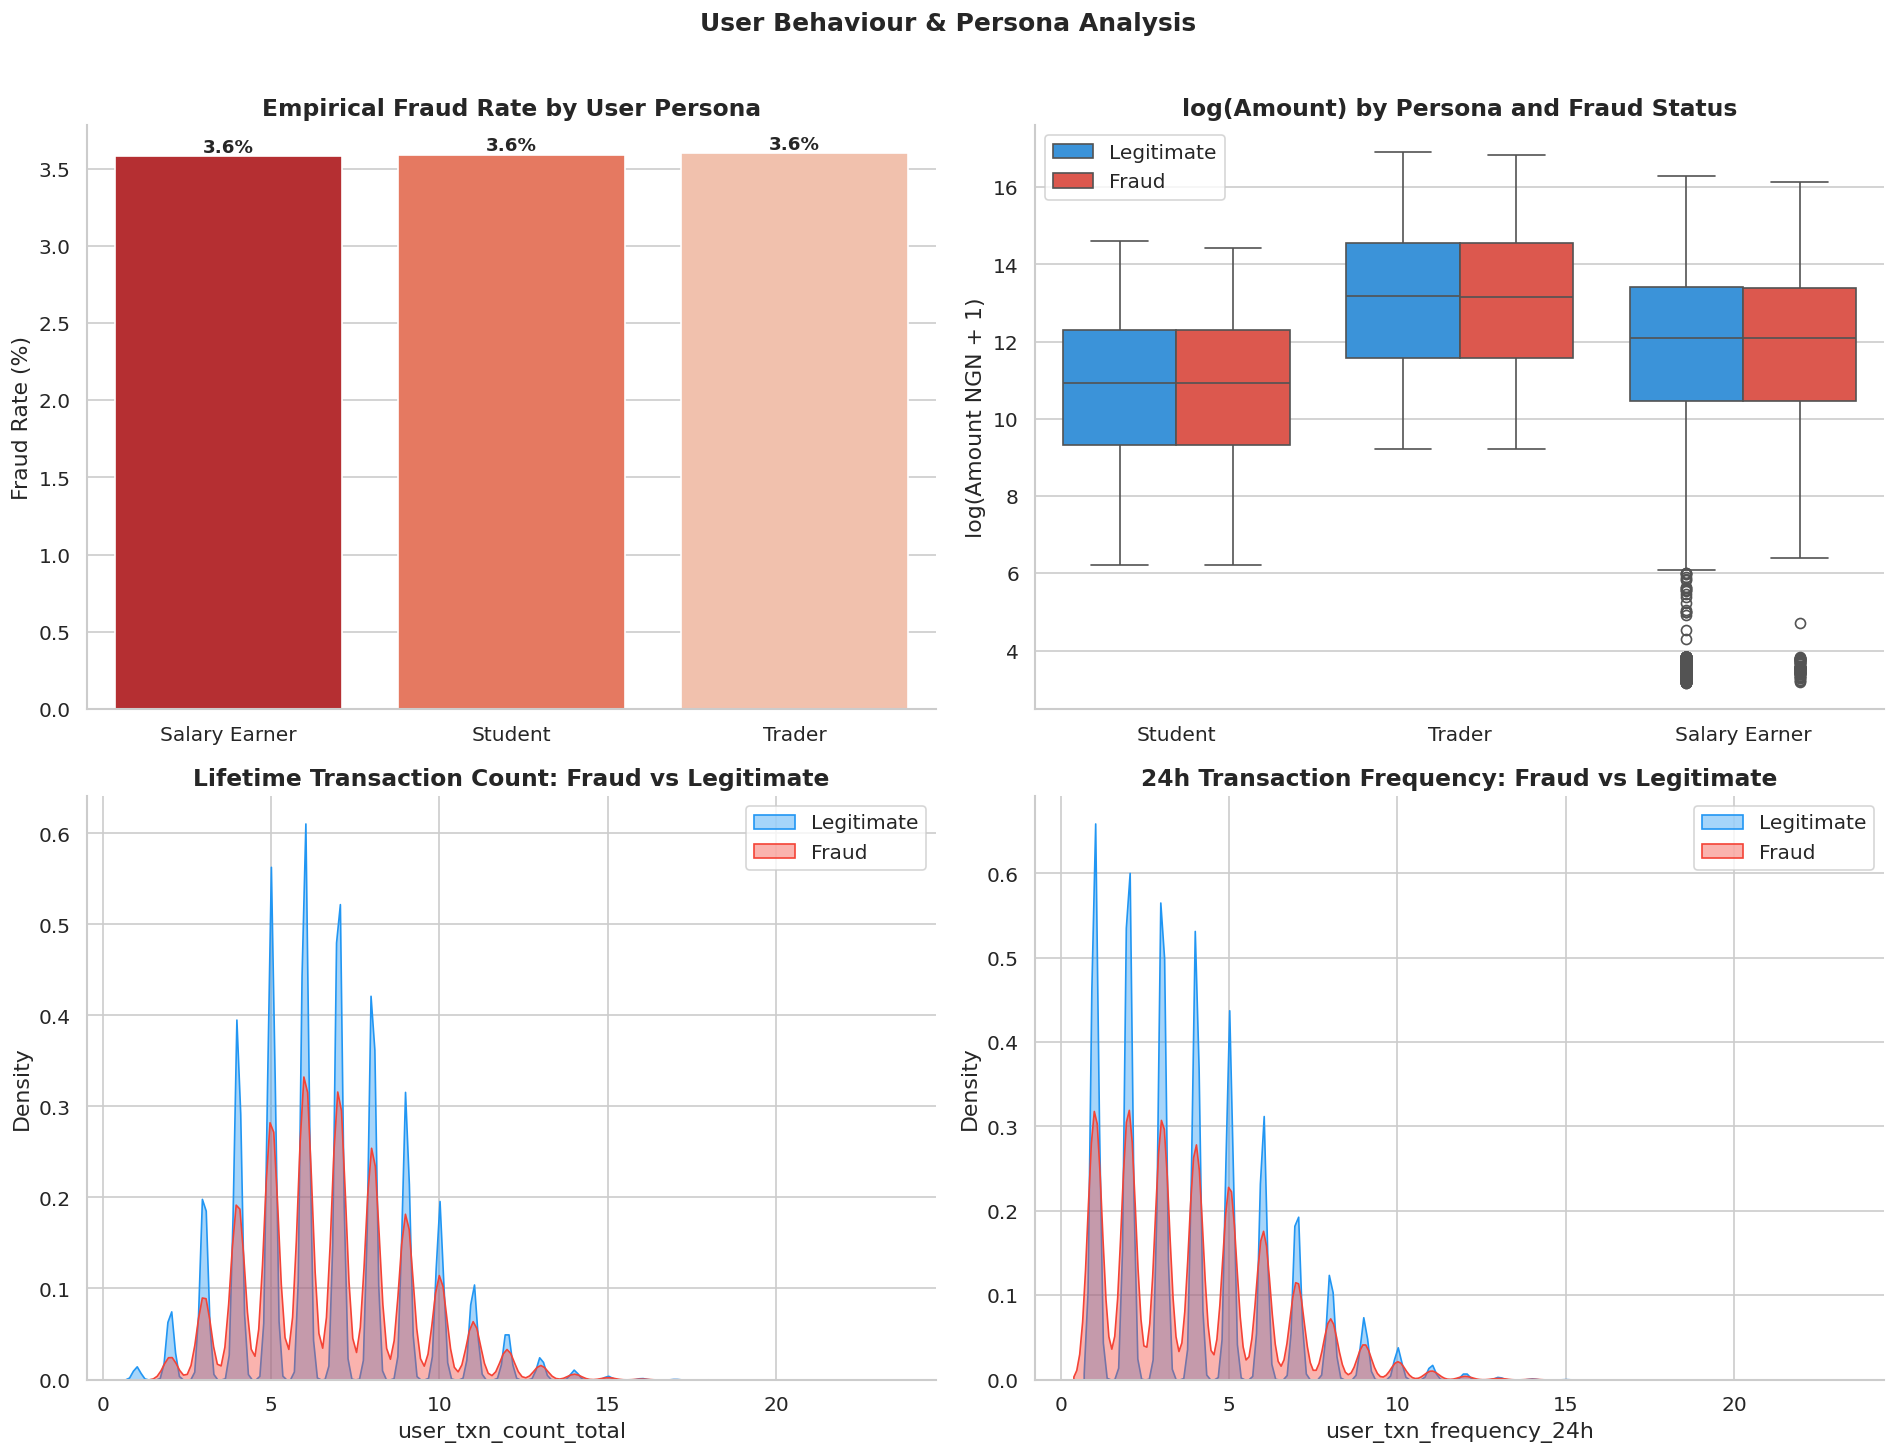

In [20]:
# User Behaviour & Persona Analysis

persona_stats = (
    data.groupby("sender_persona")
    .agg(
        total=("is_fraud", "count"),
        fraud_count=("is_fraud", "sum"),
        avg_amount=("amount_ngn", "mean"),
        median_amount=("amount_ngn", "median"),
        persona_fraud_risk=("persona_fraud_risk", "first")
    )
    .reset_index()
)
persona_stats["empirical_fraud_rate"] = (
    persona_stats["fraud_count"] / persona_stats["total"] * 100
).round(2)

print("=" * 65)
print("USER PERSONA ANALYSIS")
print("=" * 65)
print(persona_stats.to_string(index=False))

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Fraud rate by persona
sns.barplot(
    data=persona_stats,
    x="sender_persona", y="empirical_fraud_rate",
    palette="Reds_r", ax=axes[0, 0]
)
axes[0, 0].set_title("Empirical Fraud Rate by User Persona")
axes[0, 0].set_xlabel("")
axes[0, 0].set_ylabel("Fraud Rate (%)")
for p in axes[0, 0].patches:
    axes[0, 0].annotate(
        f"{p.get_height():.1f}%",
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha="center", va="bottom", fontsize=11, fontweight="bold"
    )

# Amount distribution by persona and fraud status
data["label"] = data["is_fraud"].map(FRAUD_LABELS)
data["log_amount"] = np.log1p(data["amount_ngn"])
sns.boxplot(
    data=data, x="sender_persona", y="log_amount",
    hue="label",
    palette={"Legitimate": "#2196F3", "Fraud": "#F44336"},
    ax=axes[0, 1]
)
axes[0, 1].set_title("log(Amount) by Persona and Fraud Status")
axes[0, 1].set_xlabel("")
axes[0, 1].set_ylabel("log(Amount NGN + 1)")
axes[0, 1].legend(title="")

# User behavioural features: fraud vs legit
for ax, feature, title in [
    (axes[1, 0], "user_txn_count_total", "Lifetime Transaction Count"),
    (axes[1, 1], "user_txn_frequency_24h", "24h Transaction Frequency")
]:
    sns.kdeplot(
        data=data[data["is_fraud"] == 0],
        x=feature, ax=ax,
        color="#2196F3", label="Legitimate", fill=True, alpha=0.4
    )
    sns.kdeplot(
        data=data[data["is_fraud"] == 1],
        x=feature, ax=ax,
        color="#F44336", label="Fraud", fill=True, alpha=0.4
    )
    ax.set_title(f"{title}: Fraud vs Legitimate")
    ax.set_xlabel(feature)
    ax.legend()

plt.suptitle("User Behaviour & Persona Analysis",
             fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("eda_visuals/user_persona_analysis.png", bbox_inches="tight")
plt.show()

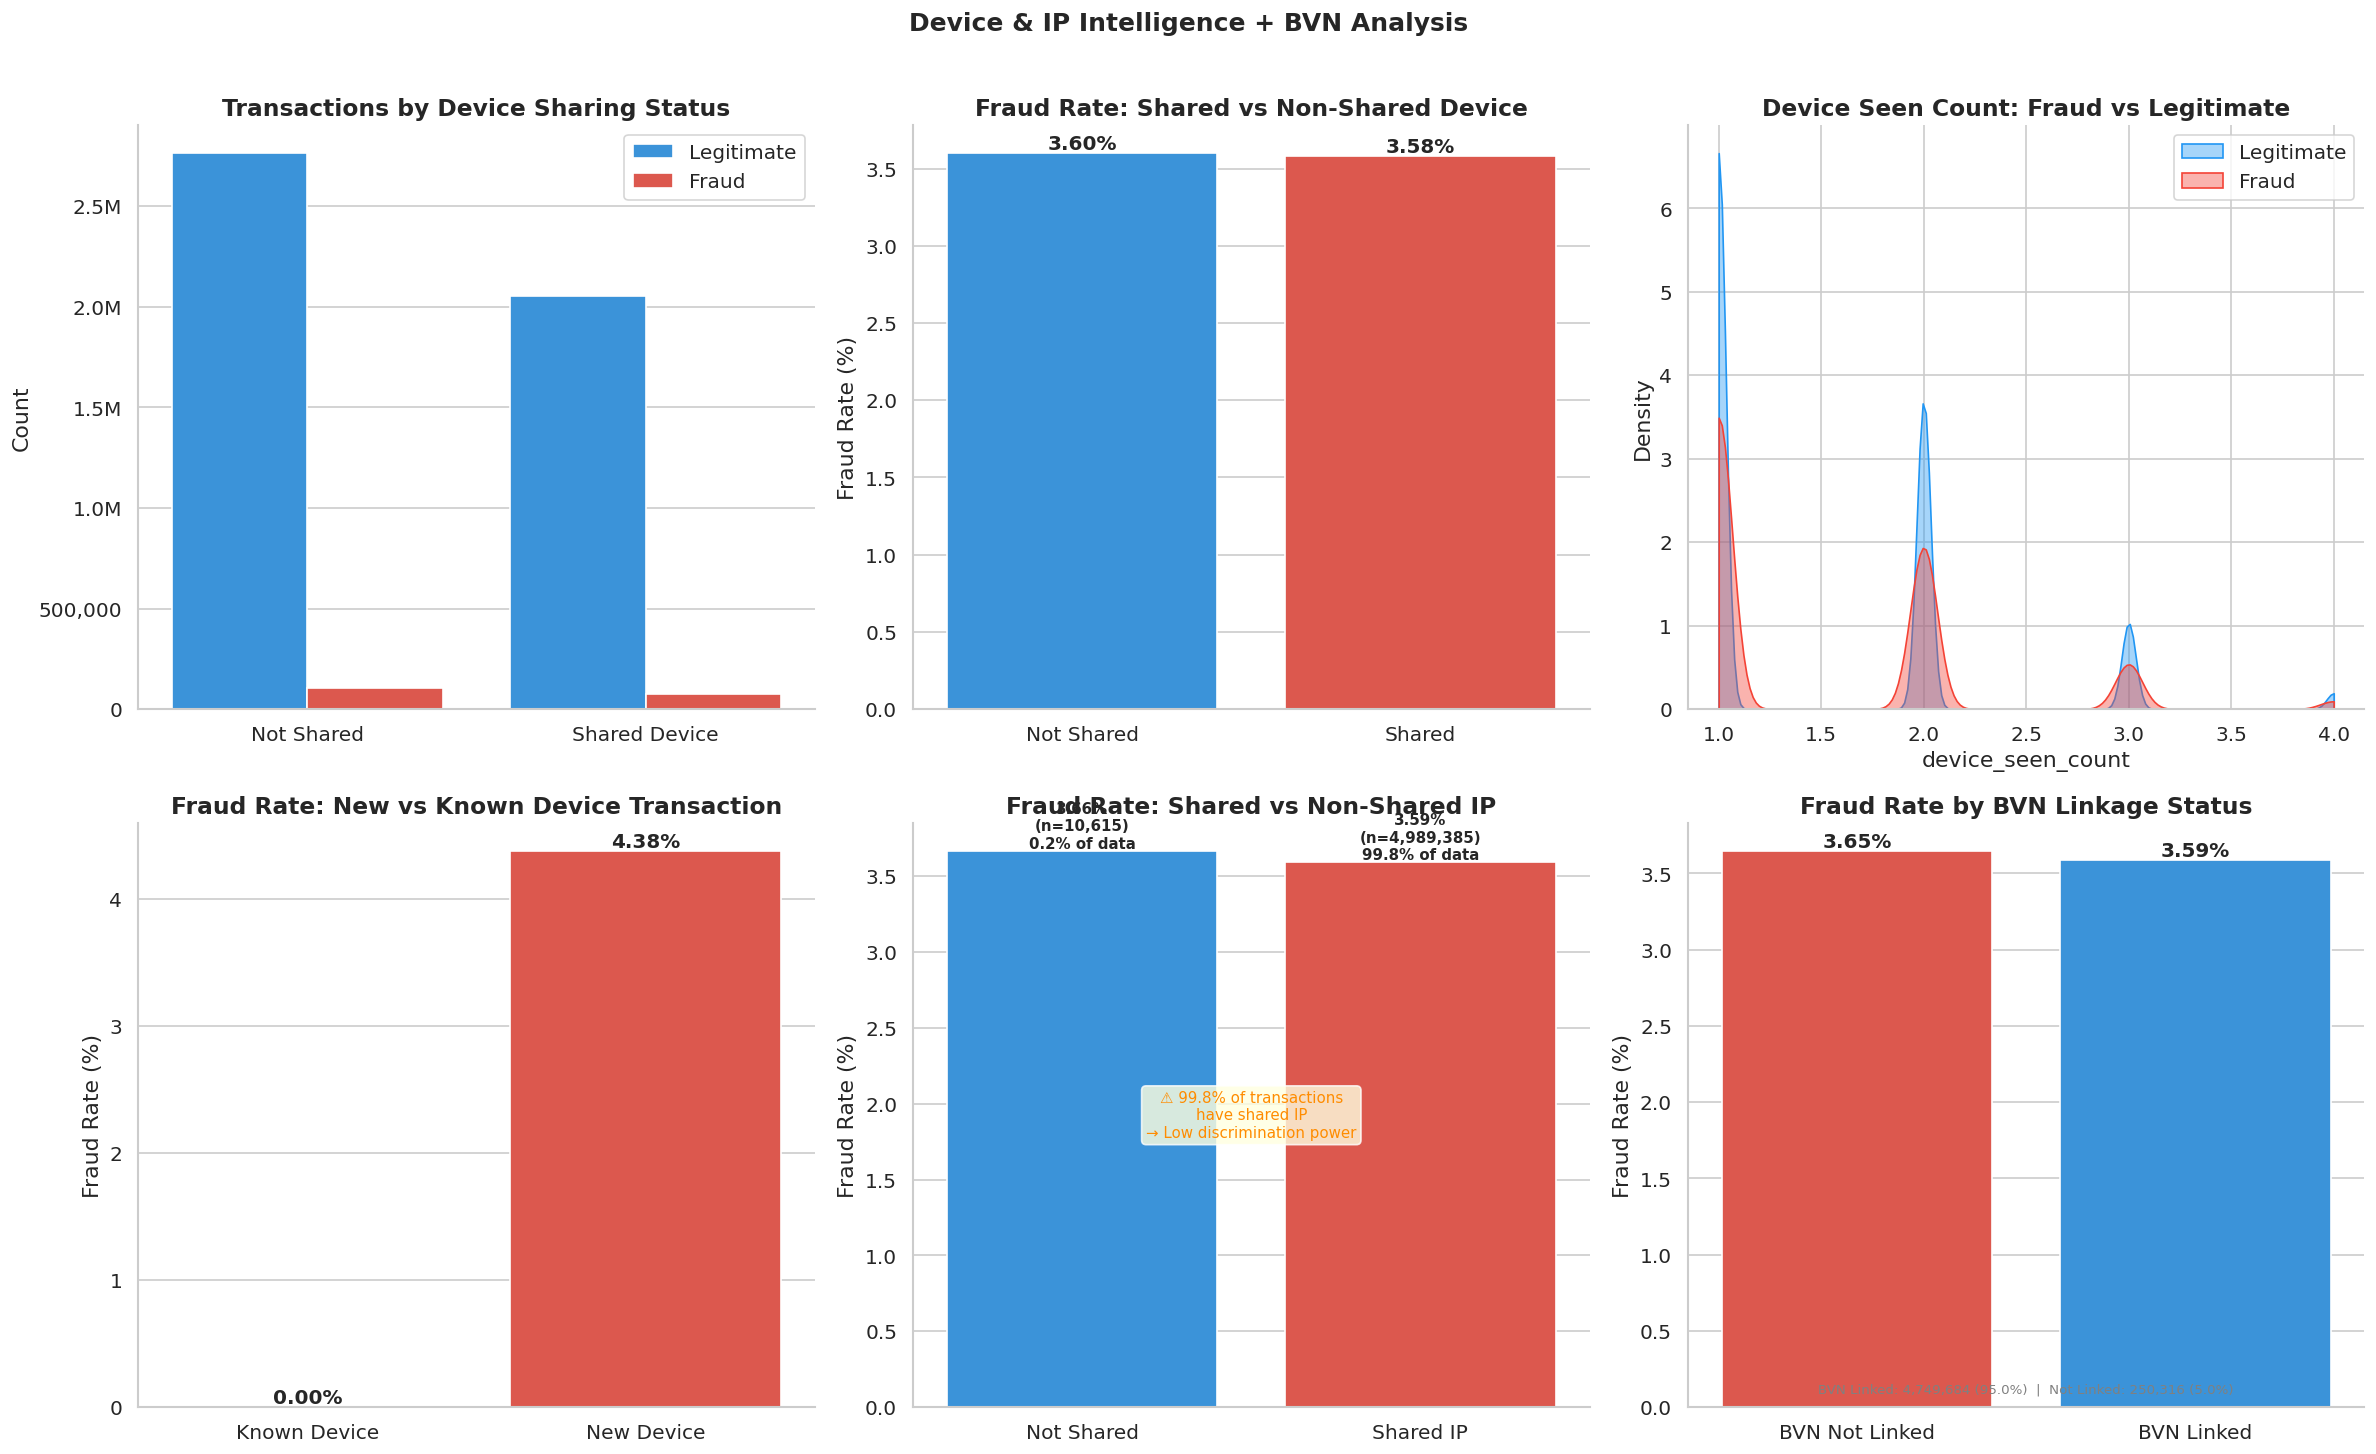

In [21]:
# Device & IP Intelligence + BVN Analysis (CORRECTED)

# --- Cast bool columns to int for groupby compatibility ---
bool_cols = ["bvn_linked", "new_device_transaction", "geospatial_velocity_anomaly"]
for col in bool_cols:
    data[col] = data[col].astype(int)

fig, axes = plt.subplots(2, 3, figsize=(20, 12))

# ── CHART 1: Transaction volume by device sharing status ──
shared_device_cross = (
    data.groupby(["is_device_shared", "is_fraud"])
    .size()
    .reset_index(name="count")
)
shared_device_cross["label"]  = shared_device_cross["is_fraud"].map(FRAUD_LABELS)
shared_device_cross["shared"] = shared_device_cross["is_device_shared"].map(
    {0: "Not Shared", 1: "Shared Device"}
)
sns.barplot(
    data=shared_device_cross,
    x="shared", y="count", hue="label",
    palette={"Legitimate": "#2196F3", "Fraud": "#F44336"},
    ax=axes[0, 0]
)
axes[0, 0].set_title("Transactions by Device Sharing Status")
axes[0, 0].set_xlabel("")
axes[0, 0].set_ylabel("Count")
axes[0, 0].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M" if x >= 1e6 else f"{x:,.0f}")
)
axes[0, 0].legend(title="")

# ── CHART 2: Fraud rate — shared vs not shared device ──
device_fraud_rate = (
    data.groupby("is_device_shared")["is_fraud"]
    .mean()
    .mul(100)
    .reset_index()
)
device_fraud_rate.columns = ["is_device_shared", "fraud_rate"]
device_fraud_rate["label"] = device_fraud_rate["is_device_shared"].map(
    {0: "Not Shared", 1: "Shared"}
)
sns.barplot(
    data=device_fraud_rate,
    x="label", y="fraud_rate",
    palette=["#2196F3", "#F44336"],
    ax=axes[0, 1]
)
axes[0, 1].set_title("Fraud Rate: Shared vs Non-Shared Device")
axes[0, 1].set_xlabel("")
axes[0, 1].set_ylabel("Fraud Rate (%)")
for p in axes[0, 1].patches:
    axes[0, 1].annotate(
        f"{p.get_height():.2f}%",
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha="center", va="bottom", fontsize=12, fontweight="bold"
    )

# ── CHART 3: device_seen_count distribution (fraud vs legit) ──
clip_val = data["device_seen_count"].quantile(0.99)
sns.kdeplot(
    data=data[data["is_fraud"] == 0],
    x="device_seen_count",
    ax=axes[0, 2],
    color="#2196F3", label="Legitimate",
    fill=True, alpha=0.4,
    clip=(1, clip_val)
)
sns.kdeplot(
    data=data[data["is_fraud"] == 1],
    x="device_seen_count",
    ax=axes[0, 2],
    color="#F44336", label="Fraud",
    fill=True, alpha=0.4,
    clip=(1, clip_val)
)
axes[0, 2].set_title("Device Seen Count: Fraud vs Legitimate")
axes[0, 2].set_xlabel("device_seen_count")
axes[0, 2].set_ylabel("Density")
axes[0, 2].legend()

# ── CHART 4: Fraud rate — new_device_transaction ──
new_device_fraud = (
    data.groupby("new_device_transaction")["is_fraud"]
    .mean()
    .mul(100)
    .reset_index()
)
new_device_fraud.columns = ["new_device_transaction", "fraud_rate"]
new_device_fraud["label"] = new_device_fraud["new_device_transaction"].map(
    {0: "Known Device", 1: "New Device"}
)
sns.barplot(
    data=new_device_fraud,
    x="label", y="fraud_rate",
    palette=["#2196F3", "#F44336"],
    ax=axes[1, 0]
)
axes[1, 0].set_title("Fraud Rate: New vs Known Device Transaction")
axes[1, 0].set_xlabel("")
axes[1, 0].set_ylabel("Fraud Rate (%)")
for p in axes[1, 0].patches:
    axes[1, 0].annotate(
        f"{p.get_height():.2f}%",
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha="center", va="bottom", fontsize=12, fontweight="bold"
    )

# ── CHART 5: Fraud rate — is_ip_shared ──
# NOTE: 99.8% of all transactions have is_ip_shared=1
# This means the feature has near-zero discrimination power
# We plot it but annotate the imbalance clearly
ip_fraud_rate = (
    data.groupby("is_ip_shared")["is_fraud"]
    .mean()
    .mul(100)
    .reset_index()
)
ip_fraud_rate.columns = ["is_ip_shared", "fraud_rate"]
ip_fraud_rate["label"] = ip_fraud_rate["is_ip_shared"].map(
    {0: "Not Shared", 1: "Shared IP"}
)

# How many transactions per group (for annotation)
ip_counts = data["is_ip_shared"].value_counts()

sns.barplot(
    data=ip_fraud_rate,
    x="label", y="fraud_rate",
    palette=["#2196F3", "#F44336"],
    ax=axes[1, 1]
)
axes[1, 1].set_title("Fraud Rate: Shared vs Non-Shared IP")
axes[1, 1].set_xlabel("")
axes[1, 1].set_ylabel("Fraud Rate (%)")
for p, (idx, row) in zip(axes[1, 1].patches, ip_fraud_rate.iterrows()):
    count = ip_counts.get(row["is_ip_shared"], 0)
    pct_of_total = count / len(data) * 100
    axes[1, 1].annotate(
        f"{p.get_height():.2f}%\n(n={count:,})\n{pct_of_total:.1f}% of data",
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha="center", va="bottom", fontsize=9, fontweight="bold"
    )
axes[1, 1].text(
    0.5, 0.5,
    "⚠️ 99.8% of transactions\nhave shared IP\n→ Low discrimination power",
    transform=axes[1, 1].transAxes,
    ha="center", va="center",
    fontsize=9, color="darkorange",
    bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow", alpha=0.8)
)

# ── CHART 6: Fraud rate — BVN linkage ──
bvn_fraud_rate = (
    data.groupby("bvn_linked")["is_fraud"]
    .mean()
    .mul(100)
    .reset_index()
)
bvn_fraud_rate.columns = ["bvn_linked", "fraud_rate"]
bvn_fraud_rate["label"] = bvn_fraud_rate["bvn_linked"].map(
    {0: "BVN Not Linked", 1: "BVN Linked"}
)
sns.barplot(
    data=bvn_fraud_rate,
    x="label", y="fraud_rate",
    palette=["#F44336", "#2196F3"],   # red for not linked (higher risk)
    ax=axes[1, 2]
)
axes[1, 2].set_title("Fraud Rate by BVN Linkage Status")
axes[1, 2].set_xlabel("")
axes[1, 2].set_ylabel("Fraud Rate (%)")
for p in axes[1, 2].patches:
    axes[1, 2].annotate(
        f"{p.get_height():.2f}%",
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha="center", va="bottom", fontsize=12, fontweight="bold"
    )
# Add count context
bvn_counts = data["bvn_linked"].value_counts()
axes[1, 2].text(
    0.5, 0.02,
    f"BVN Linked: {bvn_counts.get(1, 0):,} ({bvn_counts.get(1,0)/len(data)*100:.1f}%)"
    f"  |  Not Linked: {bvn_counts.get(0, 0):,} ({bvn_counts.get(0,0)/len(data)*100:.1f}%)",
    transform=axes[1, 2].transAxes,
    ha="center", va="bottom", fontsize=8, color="gray"
)

plt.suptitle("Device & IP Intelligence + BVN Analysis",
             fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("eda_visuals/device_ip_bvn_analysis.png", bbox_inches="tight")
plt.show()

In [22]:
# ── Summary table ──
print("\n" + "=" * 65)
print("DEVICE & IP INTELLIGENCE SUMMARY")
print("=" * 65)

summary_rows = []

for col, label_map in [
    ("is_device_shared", {0: "Not Shared", 1: "Shared Device"}),
    ("new_device_transaction", {0: "Known Device", 1: "New Device"}),
    ("is_ip_shared", {0: "Not Shared IP", 1: "Shared IP"}),
    ("bvn_linked", {0: "BVN Not Linked", 1: "BVN Linked"}),
    ("geospatial_velocity_anomaly", {0: "No Anomaly", 1: "Anomaly"}),
]:
    for val, label in label_map.items():
        subset = data[data[col] == val]
        fraud_rate = subset["is_fraud"].mean() * 100
        count = len(subset)
        pct = count / len(data) * 100
        summary_rows.append({
            "Feature": col,
            "Value": label,
            "Count": f"{count:,}",
            "% of Data": f"{pct:.1f}%",
            "Fraud Rate": f"{fraud_rate:.2f}%"
        })

summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index=False))

print("\n" + "=" * 65)
print(" DATA QUALITY FLAGS IDENTIFIED")
print("=" * 65)
print("""
  1. is_night_txn   → nunique=1 (single value across 5M rows)
                      DEAD FEATURE — drop before training

  2. is_ip_shared   → 99.8% of transactions flagged as shared
                      Near-zero variance → weak discriminator
                      Investigate ip_seen_count instead (176 unique values)

  3. location       → only 10 unique cities
                      Dataset card claimed 20, possible data issue

  4. fraud_type     → only 3 unique values
                      Dataset card implied more categories
""")


DEVICE & IP INTELLIGENCE SUMMARY
                    Feature          Value     Count % of Data Fraud Rate
           is_device_shared     Not Shared 2,867,949     57.4%      3.60%
           is_device_shared  Shared Device 2,132,051     42.6%      3.58%
     new_device_transaction   Known Device   896,459     17.9%      0.00%
     new_device_transaction     New Device 4,103,541     82.1%      4.38%
               is_ip_shared  Not Shared IP    10,615      0.2%      3.66%
               is_ip_shared      Shared IP 4,989,385     99.8%      3.59%
                 bvn_linked BVN Not Linked   250,316      5.0%      3.65%
                 bvn_linked     BVN Linked 4,749,684     95.0%      3.59%
geospatial_velocity_anomaly     No Anomaly 4,999,614    100.0%      3.59%
geospatial_velocity_anomaly        Anomaly       386      0.0%      3.11%

 DATA QUALITY FLAGS IDENTIFIED

  1. is_night_txn   → nunique=1 (single value across 5M rows)
                      DEAD FEATURE — drop before training


#### Feature Correlation & Leakage Detection (CORRECTED) 

Two goals:

1. CORRELATION MATRIX 

Which numeric features are most predictive of is_fraud? 

Which features are redundant (highly correlated with each other)? Tree models tolerate multicollinearity but knowing it helps with feature selection and interpretation.

2. LEAKAGE DETECTION

Any feature with suspiciously high correlation to is_fraud must be investigated before training. In this dataset:
fraud_type is a direct label leak (drop it)
merchant_fraud_rate / location_fraud_risk may leak depending on how they were computed

3. BINARY FEATURE DISCRIMINATION

Point-Biserial correlation for all confirmed binary flags.
Corrected column names from above analysis applied here as well.

In [23]:
# --- Cast bool columns to int for groupby compatibility ---
bool_cols = ["bvn_linked", "new_device_transaction", "geospatial_velocity_anomaly"]

for col in bool_cols:
    if data[col].dtype == bool:
        data[col] = data[col].astype(int)

# --- Rebuild numeric feature list including derived columns ---
# Exclude: IDs, target, string columns, derived label/log columns
# we added in earlier cells for plotting purposes only

EXCLUDE_COLS = [
    "transaction_id", "sender_account", "receiver_account",   # IDs
    "is_fraud",                                               # target
    "label", "week_label",                                    # plot helpers
    "log_amount",                                             # derived plot col
    "hour", "day_of_week", "day_of_month", "month",           # derived in Cell 9
                                                              # (already in txn_hour)
]

NUMERIC_FEATURES_CORRECTED = [
    col for col in data.select_dtypes(include=[np.number]).columns
    if col not in EXCLUDE_COLS
]

print("=" * 65)
print(f"NUMERIC FEATURES FOR CORRELATION ({len(NUMERIC_FEATURES_CORRECTED)} total)")
print("=" * 65)

for i, col in enumerate(NUMERIC_FEATURES_CORRECTED, 1):
    print(f"  {i:>2}. {col}")

NUMERIC FEATURES FOR CORRELATION (29 total)
   1. time_since_last_transaction
   2. spending_deviation_score
   3. velocity_score
   4. geo_anomaly_score
   5. amount_ngn
   6. bvn_linked
   7. new_device_transaction
   8. geospatial_velocity_anomaly
   9. txn_hour
  10. is_weekend
  11. is_salary_week
  12. is_night_txn
  13. device_seen_count
  14. is_device_shared
  15. ip_seen_count
  16. is_ip_shared
  17. user_txn_count_total
  18. user_avg_txn_amt
  19. user_std_txn_amt
  20. user_txn_frequency_24h
  21. txn_count_last_1h
  22. txn_count_last_24h
  23. total_amount_last_1h
  24. time_since_last
  25. avg_gap_between_txns
  26. merchant_fraud_rate
  27. channel_risk_score
  28. persona_fraud_risk
  29. location_fraud_risk


In [24]:
# ── SECTION 1: Correlation with is_fraud ──────────────────────
print("\n" + "=" * 65)
print("FEATURE CORRELATION WITH is_fraud")
print("=" * 65)

correlations = (
    data[NUMERIC_FEATURES_CORRECTED + ["is_fraud"]]
    .corr()["is_fraud"]
    .drop("is_fraud")
    .sort_values(key=abs, ascending=False)
    .reset_index()
)
correlations.columns = ["Feature", "Correlation"]
correlations["Abs_Correlation"] = correlations["Correlation"].abs()
correlations["Direction"] = correlations["Correlation"].apply(
    lambda x: "↑ Positive" if x > 0 else "↓ Negative"
)
correlations["Signal Strength"] = correlations["Abs_Correlation"].apply(
    lambda x: "🔴 Very Strong" if x > 0.5
    else "🟠 Strong"      if x > 0.3
    else "🟡 Moderate"    if x > 0.1
    else "🟢 Weak"
)

print(correlations.drop("Abs_Correlation", axis=1).to_string(index=False))


FEATURE CORRELATION WITH is_fraud


                    Feature  Correlation  Direction Signal Strength
     new_device_transaction     0.090207 ↑ Positive          🟢 Weak
       user_txn_count_total     0.017618 ↑ Positive          🟢 Weak
          txn_count_last_1h     0.009497 ↑ Positive          🟢 Weak
     user_txn_frequency_24h     0.009497 ↑ Positive          🟢 Weak
         txn_count_last_24h     0.009497 ↑ Positive          🟢 Weak
       total_amount_last_1h     0.003753 ↑ Positive          🟢 Weak
            time_since_last    -0.002401 ↓ Negative          🟢 Weak
           user_std_txn_amt     0.002384 ↑ Positive          🟢 Weak
          device_seen_count    -0.001180 ↓ Negative          🟢 Weak
        location_fraud_risk     0.000824 ↑ Positive          🟢 Weak
                   txn_hour    -0.000768 ↓ Negative          🟢 Weak
       avg_gap_between_txns    -0.000735 ↓ Negative          🟢 Weak
                 is_weekend    -0.000707 ↓ Negative          🟢 Weak
                 bvn_linked    -0.000675 ↓ Negat

In [25]:
# ── SECTION 2: Leakage Detection ──────────────────────────────
print("\n" + "=" * 65)
print("⚠️  LEAKAGE DETECTION (|correlation| > 0.4)")
print("=" * 65)
leaky = correlations[correlations["Abs_Correlation"] > 0.4]
if leaky.empty:
    print("✅ No features with |correlation| > 0.4 detected.")
else:
    print("🚨 HIGH CORRELATION — INVESTIGATE BEFORE TRAINING:\n")
    print(leaky[["Feature", "Correlation", "Signal Strength"]].to_string(index=False))
    print("""
  LEAKAGE RULES FOR THIS DATASET:
  ├── fraud_type          → DIRECT LEAK (drop — only known after fraud confirmed)
  ├── merchant_fraud_rate → CHECK: computed with .shift(1)? If yes, safe to use
  ├── location_fraud_risk → CHECK: same as above
  └── persona_fraud_risk  → Pre-assigned constant per persona, no leakage risk
    """)


⚠️  LEAKAGE DETECTION (|correlation| > 0.4)
✅ No features with |correlation| > 0.4 detected.


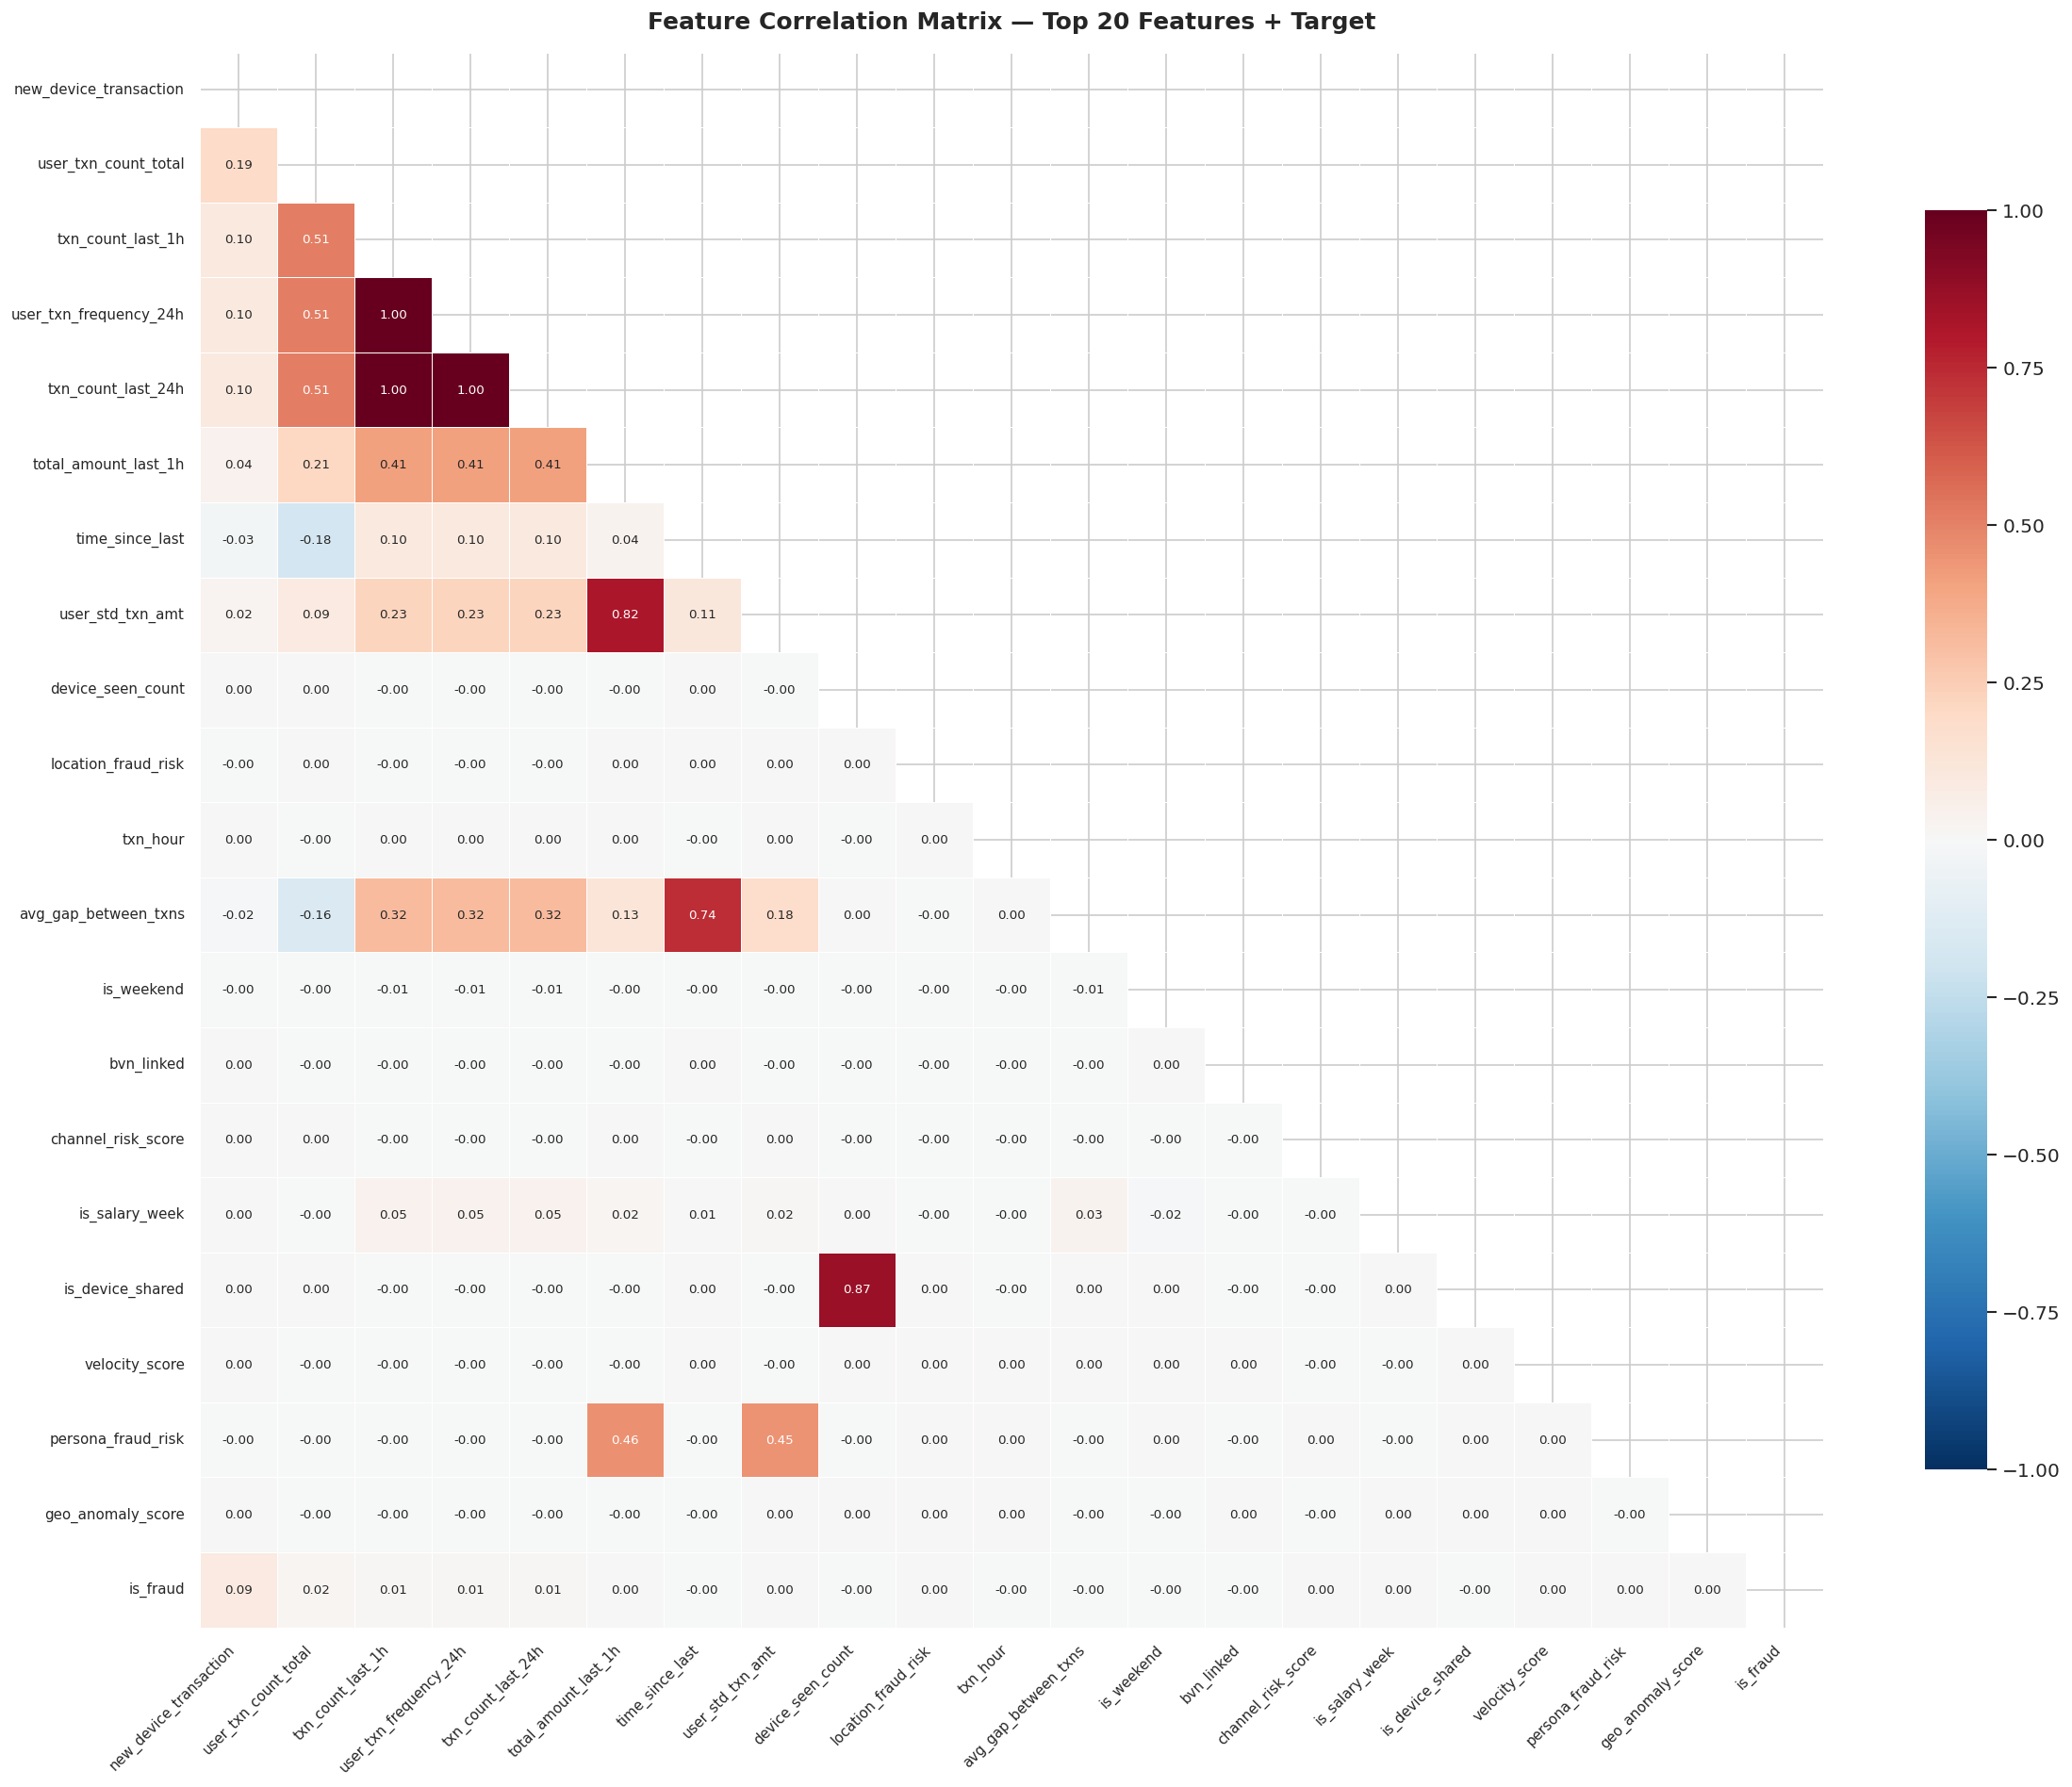

In [26]:
# ── SECTION 3: Correlation Heatmap (Top 20 features) ──────────
top_n = 20
top_features = correlations.head(top_n)["Feature"].tolist()
heatmap_cols  = top_features + ["is_fraud"]
corr_matrix   = data[heatmap_cols].corr()

fig, ax = plt.subplots(figsize=(20, 16))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    ax=ax,
    annot_kws={"size": 8},
    cbar_kws={"shrink": 0.8}
)
ax.set_title(
    f"Feature Correlation Matrix — Top {top_n} Features + Target",
    fontsize=15, fontweight="bold", pad=15
)
# Highlight the is_fraud column label
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig("eda_visuals/correlation_heatmap.png", bbox_inches="tight")
plt.show()

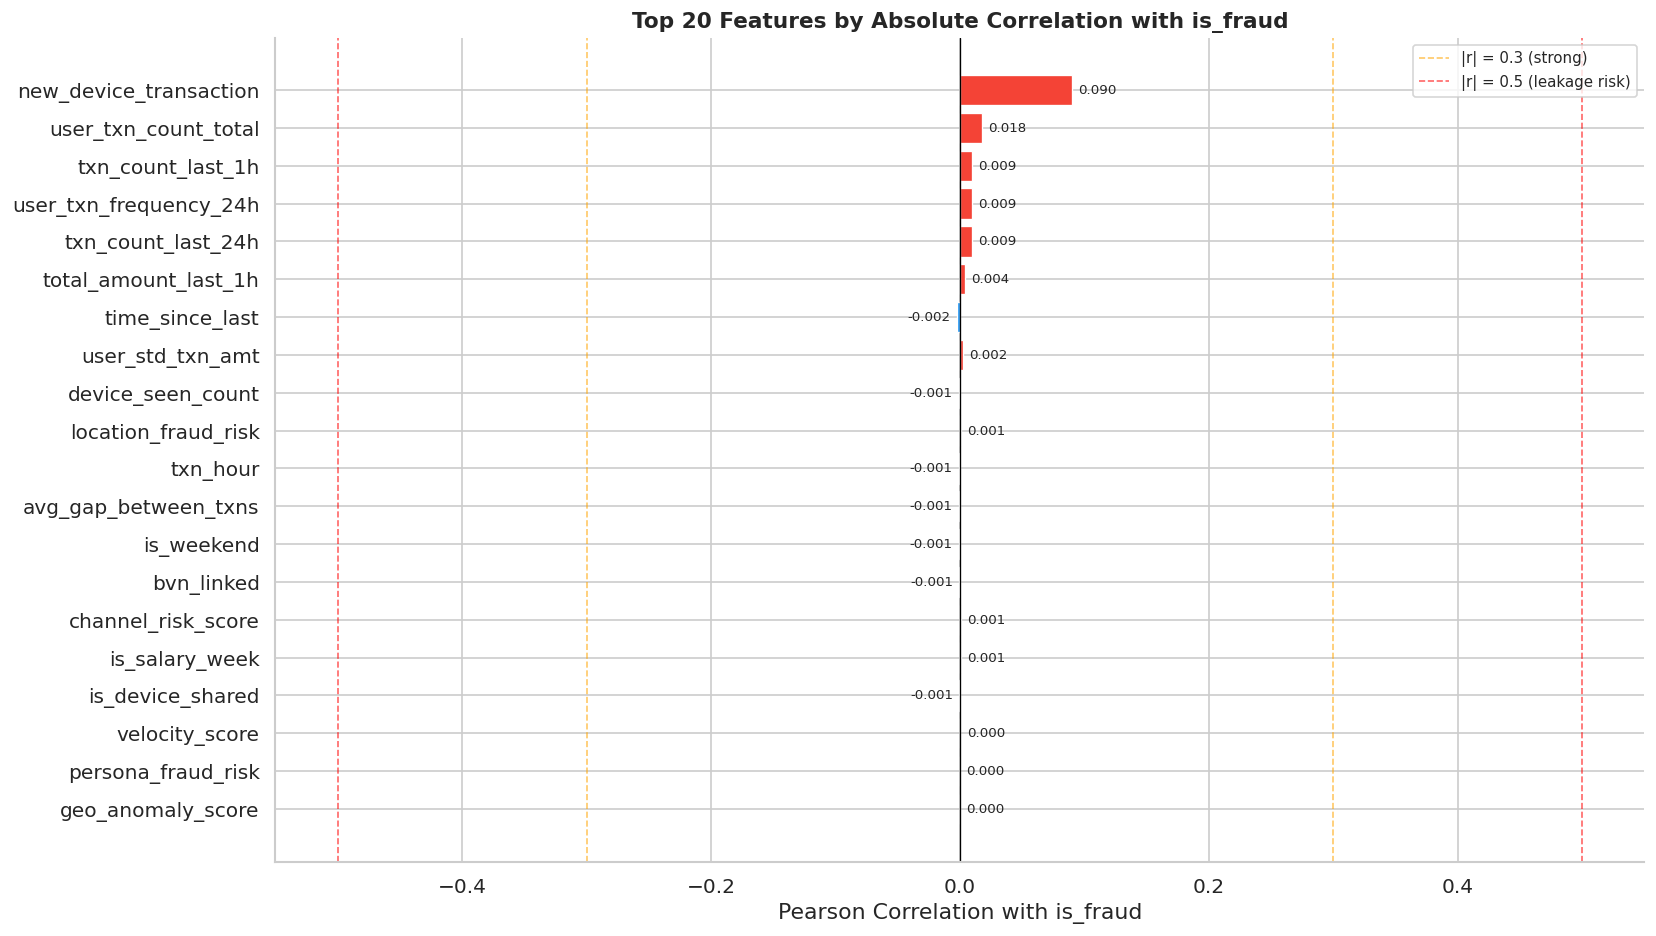

In [27]:
# ── SECTION 4: Top Feature Correlations Bar Chart ─────────────
fig, ax = plt.subplots(figsize=(14, 8))

plot_corr = correlations.head(top_n).copy()
colors = [
    "#F44336" if v > 0 else "#2196F3"
    for v in plot_corr["Correlation"]
]
bars = ax.barh(
    plot_corr["Feature"],
    plot_corr["Correlation"],
    color=colors,
    edgecolor="white",
    linewidth=0.8
)
ax.axvline(0, color="black", linewidth=0.8)
ax.axvline(0.3,  color="orange", linewidth=1, linestyle="--",
           alpha=0.6, label="|r| = 0.3 (strong)")
ax.axvline(-0.3, color="orange", linewidth=1, linestyle="--", alpha=0.6)
ax.axvline(0.5,  color="red", linewidth=1, linestyle="--",
           alpha=0.6, label="|r| = 0.5 (leakage risk)")
ax.axvline(-0.5, color="red", linewidth=1, linestyle="--", alpha=0.6)

ax.set_xlabel("Pearson Correlation with is_fraud")
ax.set_title(
    f"Top {top_n} Features by Absolute Correlation with is_fraud",
    fontsize=13, fontweight="bold"
)
ax.invert_yaxis()
ax.legend(fontsize=9)

for bar, val in zip(bars, plot_corr["Correlation"]):
    ax.text(
        val + (0.005 if val >= 0 else -0.005),
        bar.get_y() + bar.get_height() / 2,
        f"{val:.3f}",
        ha="left" if val >= 0 else "right",
        va="center", fontsize=8
    )

plt.tight_layout()
plt.savefig("eda_visuals/top_feature_correlations.png", bbox_inches="tight")
plt.show()

In [28]:
# ── SECTION 5: Point-Biserial Correlation — Binary Features ───
print("\n" + "=" * 65)
print("BINARY FEATURE DISCRIMINATION (Point-Biserial Correlation)")
print("=" * 65)
print("Corrected binary features:\n")

# CORRECTED binary feature list — verified from diagnostic output
BINARY_FEATURES_CORRECTED = [
    "bvn_linked",                   # bool → int
    "new_device_transaction",       # bool → int  (was: new_device_for_sender)
    "geospatial_velocity_anomaly",  # bool → int
    "is_device_shared",             # int64 0/1
    "is_ip_shared",                 # int64 0/1
    "is_weekend",                   # int64 0/1
    "is_salary_week",               # int64 0/1
    "is_night_txn",                 # int64 0/1 (nunique=1 — flagged as dead)
]

pbc_results = []
for feat in BINARY_FEATURES_CORRECTED:
    if feat not in data.columns:
        print(f"  ⚠️  {feat} not found in dataframe — skipping")
        continue

    unique_vals = data[feat].nunique()
    if unique_vals < 2:
        pbc_results.append({
            "Feature": feat,
            "Point-Biserial r": 0.0,
            "p-value": "N/A",
            "Significant": "❌",
            "Note": "⚠️ DEAD FEATURE (nunique=1)"
        })
        continue

    corr, pval = stats.pointbiserialr(data[feat], data["is_fraud"])
    fraud_rate_0 = data[data[feat] == 0]["is_fraud"].mean() * 100
    fraud_rate_1 = data[data[feat] == 1]["is_fraud"].mean() * 100
    lift = fraud_rate_1 / fraud_rate_0 if fraud_rate_0 > 0 else float("inf")

    pbc_results.append({
        "Feature": feat,
        "Point-Biserial r": round(corr, 4),
        "p-value": f"{pval:.2e}",
        "Fraud Rate (=0)": f"{fraud_rate_0:.2f}%",
        "Fraud Rate (=1)": f"{fraud_rate_1:.2f}%",
        "Lift (1 vs 0)": round(lift, 3),
        "Significant": "✅" if pval < 0.05 else "❌",
        "Note": (
            "⚠️ DEAD FEATURE"    if unique_vals < 2
            else "⚠️ Weak signal" if abs(corr) < 0.02
            else "✅ Useful"
        )
    })

pbc_df = pd.DataFrame(pbc_results).sort_values(
    "Point-Biserial r", key=abs, ascending=False
)
print(pbc_df.to_string(index=False))


BINARY FEATURE DISCRIMINATION (Point-Biserial Correlation)
Corrected binary features:



                    Feature  Point-Biserial r  p-value Fraud Rate (=0) Fraud Rate (=1)  Lift (1 vs 0) Significant                        Note
     new_device_transaction            0.0902 0.00e+00           0.00%           4.38%            inf           ✅                    ✅ Useful
                 bvn_linked           -0.0007 1.31e-01           3.65%           3.59%          0.984           ❌              ⚠️ Weak signal
                 is_weekend           -0.0007 1.14e-01           3.60%           3.57%          0.992           ❌              ⚠️ Weak signal
           is_device_shared           -0.0006 2.15e-01           3.60%           3.58%          0.994           ❌              ⚠️ Weak signal
             is_salary_week            0.0006 2.08e-01           3.58%           3.61%          1.006           ❌              ⚠️ Weak signal
geospatial_velocity_anomaly           -0.0002 6.11e-01           3.59%           3.11%          0.866           ❌              ⚠️ Weak signal
      

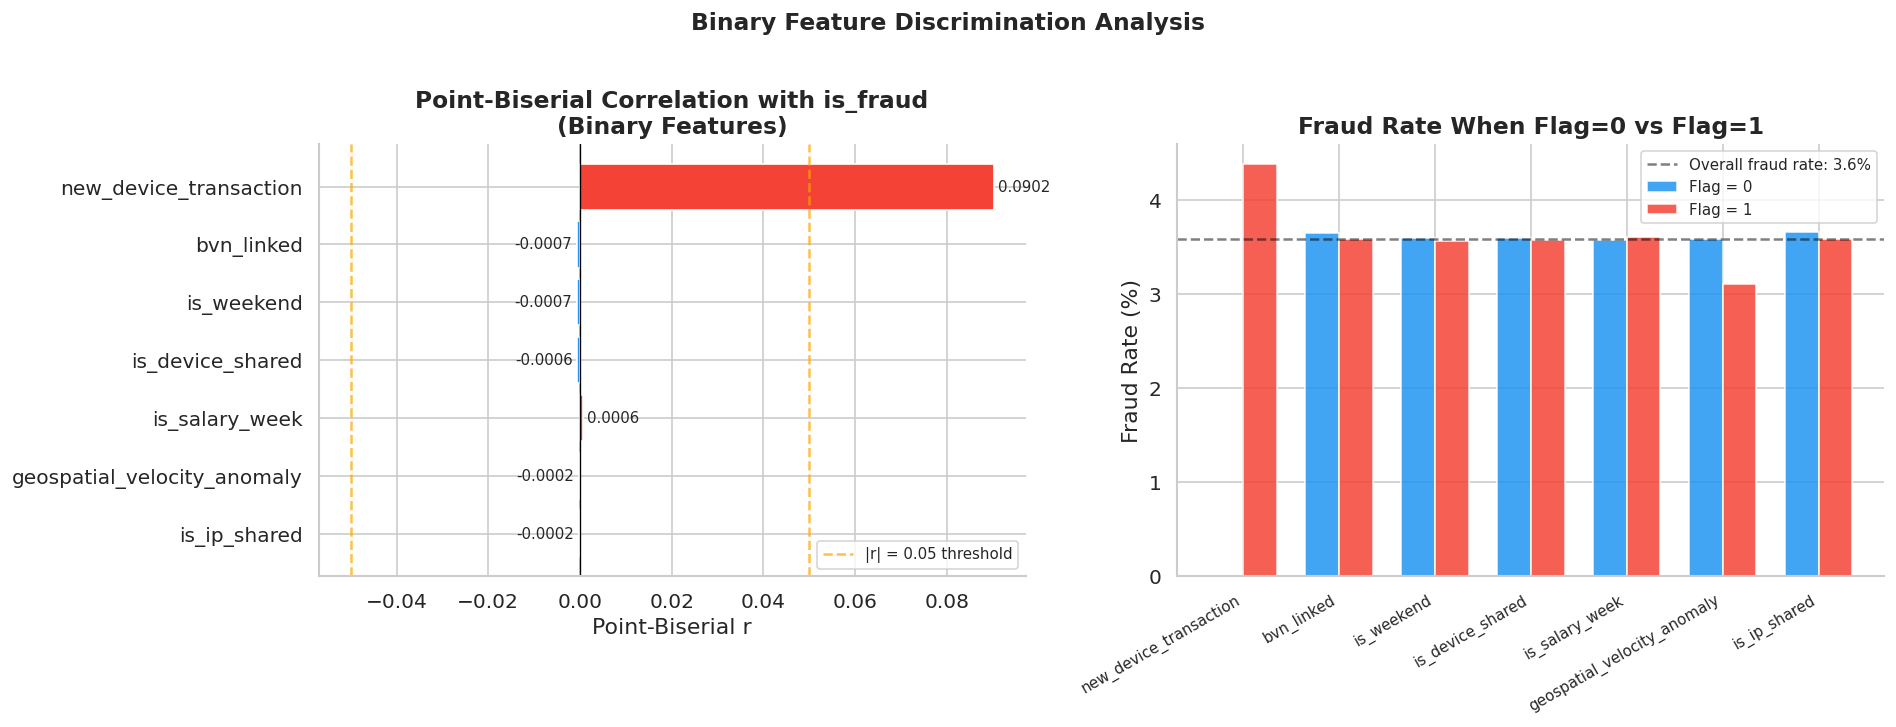

In [29]:
# ── SECTION 6: Binary Feature Lift Chart ──────────────────────
plot_pbc = pbc_df[pbc_df["Point-Biserial r"] != 0.0].copy()
plot_pbc["Point-Biserial r"] = plot_pbc["Point-Biserial r"].astype(float)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Point-Biserial r bar chart
colors_pbc = [
    "#F44336" if v > 0 else "#2196F3"
    for v in plot_pbc["Point-Biserial r"]
]
bars = axes[0].barh(
    plot_pbc["Feature"],
    plot_pbc["Point-Biserial r"],
    color=colors_pbc,
    edgecolor="white"
)
axes[0].axvline(0, color="black", linewidth=0.8)
axes[0].axvline(0.05,  color="orange", linestyle="--",
                alpha=0.7, label="|r| = 0.05 threshold")
axes[0].axvline(-0.05, color="orange", linestyle="--", alpha=0.7)
axes[0].set_title("Point-Biserial Correlation with is_fraud\n(Binary Features)")
axes[0].set_xlabel("Point-Biserial r")
axes[0].invert_yaxis()
axes[0].legend(fontsize=9)
for bar, val in zip(bars, plot_pbc["Point-Biserial r"]):
    axes[0].text(
        val + (0.001 if val >= 0 else -0.001),
        bar.get_y() + bar.get_height() / 2,
        f"{val:.4f}",
        ha="left" if val >= 0 else "right",
        va="center", fontsize=9
    )

# Fraud rate when flag=0 vs flag=1
x_pos    = np.arange(len(plot_pbc))
width    = 0.35
rate_0   = plot_pbc["Fraud Rate (=0)"].str.replace("%", "").astype(float)
rate_1   = plot_pbc["Fraud Rate (=1)"].str.replace("%", "").astype(float)

axes[1].bar(x_pos - width/2, rate_0, width,
            label="Flag = 0", color="#2196F3", alpha=0.85, edgecolor="white")
axes[1].bar(x_pos + width/2, rate_1, width,
            label="Flag = 1", color="#F44336", alpha=0.85, edgecolor="white")
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(
    plot_pbc["Feature"], rotation=30, ha="right", fontsize=9
)
axes[1].set_title("Fraud Rate When Flag=0 vs Flag=1")
axes[1].set_ylabel("Fraud Rate (%)")
axes[1].legend(title="")
axes[1].axhline(
    data["is_fraud"].mean() * 100,
    color="black", linestyle="--", alpha=0.5,
    label=f"Overall fraud rate: {data['is_fraud'].mean()*100:.1f}%"
)
axes[1].legend(fontsize=9)

plt.suptitle("Binary Feature Discrimination Analysis",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("eda_visuals/binary_feature_analysis.png", bbox_inches="tight")
plt.show()

In [30]:
# ── SECTION 7: Multicollinearity Check ────────────────────────
print("\n" + "=" * 65)
print("MULTICOLLINEARITY CHECK (|r| > 0.7 between features)")
print("=" * 65)
print("Highly correlated feature PAIRS (excluding target):\n")

corr_no_target = data[NUMERIC_FEATURES_CORRECTED].corr()
high_corr_pairs = []

for i in range(len(corr_no_target.columns)):
    for j in range(i + 1, len(corr_no_target.columns)):
        r = corr_no_target.iloc[i, j]
        if abs(r) > 0.7:
            high_corr_pairs.append({
                "Feature A": corr_no_target.columns[i],
                "Feature B": corr_no_target.columns[j],
                "Correlation": round(r, 4),
                "Action": (
                    "🔴 Consider dropping one"  if abs(r) > 0.9
                    else "🟠 Monitor — may be redundant"
                )
            })

if not high_corr_pairs:
    print("✅ No feature pairs with |r| > 0.7 found.")
else:
    mc_df = pd.DataFrame(high_corr_pairs).sort_values(
        "Correlation", key=abs, ascending=False
    )
    print(mc_df.to_string(index=False))


MULTICOLLINEARITY CHECK (|r| > 0.7 between features)
Highly correlated feature PAIRS (excluding target):

             Feature A            Feature B  Correlation                       Action
user_txn_frequency_24h   txn_count_last_24h       1.0000      🔴 Consider dropping one
     txn_count_last_1h   txn_count_last_24h       1.0000      🔴 Consider dropping one
user_txn_frequency_24h    txn_count_last_1h       1.0000      🔴 Consider dropping one
     device_seen_count     is_device_shared       0.8650 🟠 Monitor — may be redundant
      user_std_txn_amt total_amount_last_1h       0.8175 🟠 Monitor — may be redundant
       time_since_last avg_gap_between_txns       0.7364 🟠 Monitor — may be redundant
      user_avg_txn_amt total_amount_last_1h       0.7356 🟠 Monitor — may be redundant
            amount_ngn     user_avg_txn_amt       0.7091 🟠 Monitor — may be redundant
